# 1. Libraries and variables

## 1.1 Libraries

In [91]:
#!pip install odfpy

In [248]:
import pandas as pd
import numpy as np
from dotenv import dotenv_values
from sqlalchemy import create_engine, types
from sqlalchemy import text
from sqlalchemy.dialects.postgresql import JSON as postgres_json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from scipy import stats
import seaborn as sns

## 1.2 Variables

In [111]:
# Variables for controlling the execution of certain cells
 
# Control of uploading data to PostgreSQL database 
UPLOAD_TO_DB = False

# Control of creation of view
CREATE_VIEW = False

# Control of mapping of regions and subregions
MAPPING_REGIONS = False

# Control of checks
CONTROL = False


## 1.3 Common Configurations for all Hypothesis

In [112]:
# Configurations for all airports

# IATA Codes alphabetical order
labels = {
    "AMSTERDAM/SCHIPHOL airport": "AMS",
    "PARIS-CHARLES DE GAULLE airport": "CDG",
    "FRANKFURT/MAIN airport": "FRA",
    "ADOLFO SUAREZ MADRID-BARAJAS airport": "MAD"
}

# Colors for each airport
colors = {
    "AMSTERDAM/SCHIPHOL airport": "steelblue",
    "FRANKFURT/MAIN airport": "green",
    "ADOLFO SUAREZ MADRID-BARAJAS airport": "purple",
    "PARIS-CHARLES DE GAULLE airport": "orange"
}

# Month labels for plotting
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]


# 2. Data Handling 

## 2.1 Definition of function for reading and cleaning datasets

In [113]:
# Function for cleaning the files
# it takes 4 arguments: year (value from 2017 to 2024), data_type ( "Cargo" or "Passengers"), and country ("DE" or "ES"), and unit ("volume" or "flights")
def clean_aviation_file(year, data_type, country, unit="volume"):
    
    # SHEET NAMES ARE DIFFERENT BETWEEN GERMANY AND SPAIN, AND BETWEEN CARGO AND PASSENGERS.
    prefix = "ES_" if country == "ES" else ""
    suffix = "f" if unit == "flights" else ""

    sheet_name = f"{prefix}{data_type}{str(year)[2:]}{suffix}"
    filename = "/Users/nataliastroher/BootCamp/Capstone-Project/Data/" + f"{country}_{data_type}_{year}.xlsx"
    
    df = pd.read_excel(filename, sheet_name=sheet_name, header=8)
    
    # DROP EMPTY COLUMNS
    df = df.dropna(axis=1, how="all")
    
    # SKIP DUPLICATE HEADER ROW
    df = df.iloc[1:].reset_index(drop=True)
    
    # SAVE 'b' FLAG ROWS BEFORE CLEANING
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if unnamed_cols:
        # Find rows where any unnamed column is not NaN
        b_mask = df[unnamed_cols].notna().any(axis=1)
        if b_mask.any():
            b_df = df[b_mask][["TIME"] + unnamed_cols].copy()
            b_df["source_file"] = filename
            b_filename = f"/Users/nataliastroher/BootCamp/Capstone-Project/Data/b_flags_{country}_{data_type}_{year}.csv"
            b_df.to_csv(b_filename, index=False)
            #print(f"  ⚠️ b flags saved to {b_filename} — {b_mask.sum()} rows affected")
    
    # DROP UNNAMED COLUMNS
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    
    # REPLACE MISSING VALUES
    df = df.replace(":", np.nan)
    df = df.replace("not available", np.nan)
    
    # FILTER VALID ROUTES ONLY
    df = df[df["TIME"].str.contains(" - ", na=False)]
    
    # SPLIT TIME INTO ORIGIN & DESTINATION
    # This column name is coming from eurostat, from a double header-line, after reading into df. The actual content is routes. )  
    df[["origin", "destination"]] = df["TIME"].str.split(" - ", n=1, expand=True)
    df = df.drop(columns=["TIME"])

    # ADD NEW COLUMNS (required for the later merge of the 4 countries)
    df.insert(0, "origin_country", country)
    df.insert(2, "year", int(year))
    
    # RENAME MONTH COLUMNS FROM "2017-01" TO "01" (year has been created in the step before; redundant) 
    month_cols = {c: c.split("-")[1] for c in df.columns if "-" in str(c)}
    df = df.rename(columns=month_cols)
    
    # REORDER COLUMNS (defining a more suitable order)
    other_cols = [c for c in df.columns if c not in ["origin_country", "origin", "destination", "year"]]
    df = df[["origin_country", "origin", "destination", "year"] + other_cols]
    
    # CONVERT MONTH COLUMNS (int - if it is Passengers, float - if it is Cargo)
    month_cols = [c for c in df.columns if c not in ["origin_country", "origin", "destination", "year"]]
    if data_type == "Passengers":
        df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")
    else:
        df[month_cols] = df[month_cols].apply(pd.to_numeric, errors="coerce").astype("Float64")
    
    #print(f"✓ {filename} — shape: {df.shape}")
    return df

## 2.2 Generation of Dataframes per Country, Data Type (Passengers/Cargo), and Unit (Volume/Flights) 

In [6]:
# DEFINITION OF DICTIONARIES FOR EACH COUNTRY, DATA TYPE (Passengers/Cargo), AND UNIT (volume/flights)
passengers_dfs_de = {}
passengers_flights_dfs_de = {}
cargo_dfs_de = {}
cargo_flights_dfs_de = {}
  
passengers_dfs_es = {}
passengers_flights_dfs_es = {}  
cargo_dfs_es = {}
cargo_flights_dfs_es = {}

#YEARS TO LOOP THROUGH
years = range(2017, 2025)
   
dict_map = {
    ("DE", "Cargo", "volume"): cargo_dfs_de,
    ("DE", "Cargo", "flights"): cargo_flights_dfs_de,
    ("DE", "Passengers", "volume"): passengers_dfs_de,
    ("DE", "Passengers", "flights"): passengers_flights_dfs_de,
    ("ES", "Cargo", "volume"): cargo_dfs_es,
    ("ES", "Cargo", "flights"): cargo_flights_dfs_es,
    ("ES", "Passengers", "volume"): passengers_dfs_es,
    ("ES", "Passengers", "flights"): passengers_flights_dfs_es,
}

# CALLING OF FUNCTION 
for year in years:
    for country in ["DE", "ES"]:
        for data_type in ["Cargo", "Passengers"]:
            for unit in ["volume", "flights"]:
                target_dict = dict_map[(country, data_type, unit)]
                target_dict[f"{country}_{year}"] = clean_aviation_file(year, data_type, country, unit)

In [ ]:
# EXAMPLE RETRIEVING A SPECIFIC COUNTRY, DATA TYPE, UNIT, AND YEAR 

#passengers_flights_dfs_de["DE_2018"].head(20)

## 2.3 Unique destinations List
(required for later mapping the region, subregion, and destination country)

In [ ]:
if MAPPING_REGIONS:
    all_destinations_de_es = (
        pd.concat(
            [df["destination"] for df in passengers_dfs_de.values()] +
            [df["destination"] for df in passengers_flights_dfs_de.values()] +
            [df["destination"] for df in cargo_dfs_de.values()] + 
            [df["destination"] for df in cargo_flights_dfs_de.values()] +
        [df["destination"] for df in passengers_dfs_es.values()] +
        [df["destination"] for df in passengers_flights_dfs_es.values()] +
        [df["destination"] for df in cargo_dfs_es.values()] +
        [df["destination"] for df in cargo_flights_dfs_es.values()]
    )
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
    )
    all_destinations_de_es.to_csv("/Users/nataliastroher/BootCamp/Capstone-Project/data/all_destinations_de_es.csv", index=False)
    print("Cell executed successfully. All unique destinations from Germany and Spain have been extracted and sorted.")

In [ ]:
if CONTROL:
    all_destinations_de_es.head(20)

## 2.4 Mapping Region, Subregion, and Destination Country

In [ ]:
if MAPPING_REGIONS:
    lookup = pd.read_excel("/Users/nataliastroher/BootCamp/Capstone-Project/Data/destinations_with_regions_v2.xlsx")

    all_dicts = [
        passengers_dfs_de, passengers_flights_dfs_de,
        cargo_dfs_de, cargo_flights_dfs_de,
        passengers_dfs_es, passengers_flights_dfs_es,
        cargo_dfs_es, cargo_flights_dfs_es
    ]

    for d in all_dicts:
        for key in d:
            d[key] = d[key].merge(lookup, on="destination", how="left")

### 2.4.1 Check of Unknown Destinations

In [9]:
# Collect all unknown destinations across all dictionaries

if CONTROL: 
    unknown_dfs = []

    for d_name, d in [
        ("passengers_DE", passengers_dfs_de),
        ("passengers_flights_DE", passengers_flights_dfs_de),
        ("cargo_DE", cargo_dfs_de),
        ("cargo_flights_DE", cargo_flights_dfs_de),
        ("passengers_ES", passengers_dfs_es),
        ("passengers_flights_ES", passengers_flights_dfs_es),
        ("cargo_ES", cargo_dfs_es),
        ("cargo_flights_ES", cargo_flights_dfs_es),
    ]:
        for key, df in d.items():
            mask = df["region"].isin(["Unknown", "Unknown - Country Level"]) | df["region"].isna()
            if mask.any():
                temp = df[mask][["destination", "region", "destination_country"]].copy()
                temp["source"] = d_name
                unknown_dfs.append(temp)

    # Combine and deduplicate
    unknowns_export = pd.concat(unknown_dfs, ignore_index=True).drop_duplicates(subset=["destination"])
    unknowns_export = unknowns_export.sort_values("region")

    print(f"Unique unknown destinations: {len(unknowns_export)}")
    unknowns_export.to_csv("/Users/nataliastroher/BootCamp/Capstone-Project/Data/unknown_destinations2.csv", index=False)
    print("Saved!")

### 2.4.2 Rerun Mapping v2.0 
(after manual modification of unknown - columns needed to be dropped first)

In [84]:
if MAPPING_REGIONS:

    # 1. LOAD UPDATED LOOKUP TABLE
    lookup = pd.read_excel("/Users/nataliastroher/BootCamp/Capstone-Project/Data/destinations_with_regions_v2.xlsx")

    print(f"Lookup loaded: {len(lookup)} destinations")
    print(f"Region distribution:\n{lookup['region'].value_counts()}\n")


    # 2. APPLY LOOKUP TO ALL DICTIONARIES
    #    - Drops existing region columns first to avoid _x/_y conflicts
    #    - Then merges cleanly

    region_cols = ["region", "subregion", "destination_country"]

    all_dicts = {
        "passengers_DE":         passengers_dfs_de,
        "passengers_flights_DE": passengers_flights_dfs_de,
        "cargo_DE":              cargo_dfs_de,
        "cargo_flights_DE":      cargo_flights_dfs_de,
        "passengers_ES":         passengers_dfs_es,
        "passengers_flights_ES": passengers_flights_dfs_es,
        "cargo_ES":              cargo_dfs_es,
        "cargo_flights_ES":      cargo_flights_dfs_es,
    }

    for dict_name, d in all_dicts.items():
        print(f"Processing {dict_name}...")
        for key in d:
            # Drop existing region columns if present (avoids _x/_y conflict)
            d[key] = d[key].drop(columns=region_cols, errors="ignore")
            # Merge with updated lookup
            d[key] = d[key].merge(lookup, on="destination", how="left")
        print(f"  ✓ {len(d)} dataframes updated")

    # 3. VERIFY - Check unknowns after merge

    print("\n--- Unknown check after merge ---")
    for dict_name, d in all_dicts.items():
        for key, df in d.items():
            unknown = (df["region"] == "Unknown").sum()
            nan = df["region"].isna().sum()
            if unknown > 0 or nan > 0:
                print(f"  {dict_name} {key}: Unknown={unknown}, NaN={nan}")

    print("\nDone! All dictionaries updated with region mapping.")


## 2.5. Function 'MELT_TO_LONG' 
(for converting wide into long)


In [10]:
def melt_to_long(volume_dfs, flights_dfs, value_name):
    """
    Combines volume (passengers/cargo) and flights dictionaries into one long dataframe,
    with separate columns for the value and flights.
    """
    all_rows = []
    
    for key in volume_dfs:
        vol_df = volume_dfs[key].copy()
        flights_df = flights_dfs[key].copy()
        
        month_cols = [c for c in vol_df.columns if c.isdigit()]
        id_cols = [c for c in vol_df.columns if c not in month_cols]
        
        # Melt volume
        vol_long = vol_df.melt(
            id_vars=id_cols,
            value_vars=month_cols,
            var_name="month",
            value_name=value_name
        )
        
        # Melt flights
        flights_long = flights_df.melt(
            id_vars=id_cols,
            value_vars=month_cols,
            var_name="month",
            value_name="flights"
        )
        
        # Merge them together on the identifier columns + month
        merged = vol_long.merge(
            flights_long[id_cols + ["month", "flights"]],
            on=id_cols + ["month"],
            how="left"
        )
        
        all_rows.append(merged)
    
    return pd.concat(all_rows, ignore_index=True)

### 2.5.1 Converting Passengers (DE)

In [12]:
passengers_long_de = melt_to_long(passengers_dfs_de, passengers_flights_dfs_de, "passengers")

In [13]:
passengers_long_de.info()

<class 'pandas.DataFrame'>
RangeIndex: 225792 entries, 0 to 225791
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   origin_country  225792 non-null  str  
 1   origin          225792 non-null  str  
 2   destination     225792 non-null  str  
 3   year            225792 non-null  int64
 4   month           225792 non-null  str  
 5   passengers      76484 non-null   Int64
 6   flights         76516 non-null   Int64
dtypes: Int64(2), int64(1), str(4)
memory usage: 12.5 MB


In [59]:
passengers_long_de.head

<bound method NDFrame.head of        origin_country                      origin  \
0                  DE                     UNKNOWN   
1                  DE                     UNKNOWN   
2                  DE                     UNKNOWN   
3                  DE  BERLIN-BRANDENBURG airport   
4                  DE  BERLIN-BRANDENBURG airport   
...               ...                         ...   
225787             DE               LAAGE airport   
225788             DE               LAAGE airport   
225789             DE               LAAGE airport   
225790             DE               LAAGE airport   
225791             DE               LAAGE airport   

                                         destination  year       region  \
0       GERMANY airport - BERLIN-BRANDENBURG airport  2017       Europe   
1                  GERMANY airport - HAMBURG airport  2017       Europe   
2             GERMANY airport - BERLIN-TEGEL airport  2017       Europe   
3                    ABU DHABI IN

### 2.5.2 Converting Passengers (ES)

In [14]:
passengers_long_es = melt_to_long(passengers_dfs_es, passengers_flights_dfs_es, "passengers")

In [16]:
# Confirm both passengers and flights columns are present and correctly typed
if CONTROL:
    print(passengers_long_de.dtypes)

    # Check how many rows have NaN in passengers vs flights
    print(f"NaN passengers: {passengers_long_de['passengers'].isna().sum()}")
    print(f"NaN flights: {passengers_long_de['flights'].isna().sum()}")

    # Spot check one route to make sure passengers and flights align correctly
    sample = passengers_long_de[
        (passengers_long_de["origin"].str.contains("FRANKFURT", na=False)) &
        (passengers_long_de["destination"].str.contains("DUBAI", na=False)) &
        (passengers_long_de["year"] == 2019)
    ]
    print(sample[["origin", "destination", "year", "month", "passengers", "flights"]])


### 2.5.3 Converting Cargo (DE&ES)

In [15]:
cargo_long_de = melt_to_long(cargo_dfs_de, cargo_flights_dfs_de, "cargo")
cargo_long_es = melt_to_long(cargo_dfs_es, cargo_flights_dfs_es, "cargo")

## 2.6. Concatenating Passengers Long & Cargo Long

In [17]:
passengers_master = pd.concat([
    passengers_long_de,
    passengers_long_es
], ignore_index=True)

print(passengers_master.shape)
print(passengers_master["origin_country"].value_counts())

(428256, 7)
origin_country
DE    225792
ES    202464
Name: count, dtype: int64


In [169]:
cargo_master = pd.concat([
    cargo_long_de,
    cargo_long_es
], ignore_index=True)

print(cargo_master.shape)
print(cargo_master["origin_country"].value_counts())

(280512, 10)
origin_country
DE    165888
ES    114624
Name: count, dtype: int64


# 3. dBeaver

## 3.1 Connection

In [243]:
# DB credentials

config = dotenv_values()

In [244]:
# define variables for the login
pg_user = config['POSTGRES_USER']  
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

In [245]:
# updating the url
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

# creating the engine
engine = create_engine(url, echo=False)

## 3.2 Type dictionaries

In [173]:
# defining data types for the DB
dtype_dict_passengers = {
    'origin_country':types.String,
    'origin': types.String,
    'destination': types.String,
    'year': types.Integer,
    'region': types.String,
    'subregion':types.String,
    'destination_country': types.String,
    'month': types.Integer,
    'passengers': types.Integer,
    'flights': types.Integer
             }

In [174]:
# defining data types for the DB
dtype_dict_cargo = {
    'origin_country':types.String,
    'origin': types.String,
    'destination': types.String,
    'year': types.Integer,
    'region': types.String,
    'subregion':types.String,
    'destination_country': types.String,
    'month': types.Integer,
    'cargo': types.Float,
    'flights': types.Integer
             }

## 3.3 Creating/Updating Tables 

In [81]:
if UPLOAD_TO_DB:
    capstone_schema = 'group2'
    cargo_master.to_sql(name = 'cargo_master', 
                        con = engine, 
                        schema = capstone_schema, 
                        if_exists='append', # append used as Hendrik has already created the tables in our schema
                        #dtype=dtype_dict_cargo,
                        index=False
                        )

    passengers_master.to_sql(name = 'passengers_master', 
                        con = engine, 
                        schema = capstone_schema, 
                        if_exists='append',  # append used as Hendrik has already created the tables in our schema
                        #dtype=dtype_dict_passengers,
                        index=False
                        )
    
    print("Data uploaded to PostgreSQL database successfully.")

256

## 3.4 Filling out new columns "first year" and "last year"

In [ ]:
# columns already created by Hendrik. 
# first year and last year hold the information on when the route was first and last flown.

if UPLOAD_TO_DB:
    with engine.begin() as conn:
        conn.execute(text("""UPDATE group2.cargo_master p
                            SET 
                                first_year = route_info.first_year,
                                last_year = route_info.last_year
                            FROM (
                                SELECT 
                                    origin,
                                    destination,
                                    origin_country,
                                    MIN(year) as first_year,
                                    MAX(year) as last_year
                                FROM group2.cargo_master
                                WHERE cargo IS NOT NULL
                                GROUP BY origin, destination, origin_country
                                ) route_info
                            WHERE p.origin = route_info.origin 
                            AND p.destination = route_info.destination
                            AND p.origin_country = route_info.origin_country;"""))
    print("Columns updated successfully.")

## 3.5 Creating a view 
(for all routes that have reported during all 8 years (2017-2024) for passengers to be used in the analysis)

In [175]:
if CREATE_VIEW:
    with engine.begin() as conn:
        conn.execute(text("""
            CREATE OR REPLACE VIEW group2.passengers_core AS
            SELECT *
            FROM group2.passengers_master
            WHERE origin IN (
                'FRANKFURT/MAIN airport',
                'PARIS-CHARLES DE GAULLE airport',
                'ADOLFO SUAREZ MADRID-BARAJAS airport',
                'AMSTERDAM/SCHIPHOL airport'
            )
            AND (origin, destination, origin_country) IN (
                SELECT origin, destination, origin_country
                FROM group2.passengers_master
                WHERE passengers IS NOT NULL
                AND origin IN (
                    'FRANKFURT/MAIN airport',
                    'PARIS-CHARLES DE GAULLE airport',
                    'ADOLFO SUAREZ MADRID-BARAJAS airport',
                    'AMSTERDAM/SCHIPHOL airport'
                )
                GROUP BY origin, destination, origin_country
                HAVING 
                    COUNT(CASE WHEN year BETWEEN 2017 AND 2019 
                        AND passengers IS NOT NULL THEN 1 END) >= 12
                    AND COUNT(CASE WHEN year IN (2020, 2021) 
                        AND passengers IS NOT NULL THEN 1 END) >= 12
                    AND COUNT(CASE WHEN year BETWEEN 2022 AND 2024 
                        AND passengers IS NOT NULL THEN 1 END) >= 12
            );
        """))
    print("View recreated successfully!")





View recreated successfully!


# 4. EDA 

## 4.1 Retrieving data from db

In [22]:

passengers_core = pd.read_sql("SELECT * FROM group2.passengers_core", engine)


## 4.2 Exploring data 

In [115]:

#passengers_core.head()
passengers_core.info()
#passengers_core.describe(include='all')
#passengers_core.shape


<class 'pandas.DataFrame'>
RangeIndex: 37920 entries, 0 to 37919
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   origin_country       37920 non-null  str  
 1   origin               37920 non-null  str  
 2   destination          37920 non-null  str  
 3   year                 37920 non-null  int64
 4   region               37920 non-null  str  
 5   subregion            37920 non-null  str  
 6   destination_country  37920 non-null  str  
 7   month                37920 non-null  int64
 8   passengers           36026 non-null  Int64
 9   flights              35563 non-null  Int64
 10  first_year           37920 non-null  int64
 11  last_year            37920 non-null  int64
dtypes: Int64(2), int64(4), str(6)
memory usage: 3.5 MB


In [23]:
# Fix dtypes after loading
passengers_core['passengers'] = passengers_core['passengers'].astype('Int64')
passengers_core['flights'] = passengers_core['flights'].astype('Int64')
passengers_core['year'] = passengers_core['year'].astype(int)
passengers_core['month'] = passengers_core['month'].astype(int)

In [213]:
passengers_core.info()

<class 'pandas.DataFrame'>
RangeIndex: 37920 entries, 0 to 37919
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   origin_country       37920 non-null  str  
 1   origin               37920 non-null  str  
 2   destination          37920 non-null  str  
 3   year                 37920 non-null  int64
 4   region               37920 non-null  str  
 5   subregion            37920 non-null  str  
 6   destination_country  37920 non-null  str  
 7   month                37920 non-null  int64
 8   passengers           36026 non-null  Int64
 9   flights              35563 non-null  Int64
 10  first_year           37920 non-null  int64
 11  last_year            37920 non-null  int64
dtypes: Int64(2), int64(4), str(6)
memory usage: 3.5 MB


In [178]:
# distributions of record numbers across airports
passengers_core['origin'].value_counts(normalize=True).mul(100).round(1)

origin
FRANKFURT/MAIN airport                  27.8
AMSTERDAM/SCHIPHOL airport              27.6
PARIS-CHARLES DE GAULLE airport         26.1
ADOLFO SUAREZ MADRID-BARAJAS airport    18.5
Name: proportion, dtype: float64

In [ ]:
# How many unique routes are there per airport?
routes_per_airport = (
    passengers_core
    .groupby("origin")["destination"]
    .nunique()
)

routes_per_airport 

origin
ADOLFO SUAREZ MADRID-BARAJAS airport     73
AMSTERDAM/SCHIPHOL airport              106
FRANKFURT/MAIN airport                  110
PARIS-CHARLES DE GAULLE airport         103
Name: destination, dtype: int64

In [85]:
passengers_core["passengers"].describe()

count         36026.0
mean     35073.237773
std      28741.071558
min               0.0
25%          15434.25
50%           27157.0
75%           46522.0
max          246799.0
Name: passengers, dtype: Float64

In [ ]:
# Ghost flights - zero passengers 
ghost_flights = passengers_core[(passengers_core["passengers"] == 0) & (passengers_core["flights"] > 0)]
print(f"Ghost flight records: {len(ghost_flights)}")
print(ghost_flights.groupby(["origin", "year", "month"])[["passengers", "flights"]].sum())

In [ ]:
# Check max route
passengers_core[passengers_core["passengers"] == 246799]

,origin_country,origin,destination,year,region,subregion,destination_country,month,passengers,flights,first_year,last_year
30225,ES,ADOLFO SUAREZ MADRID-BARAJAS airport,BARCELONA/EL PRAT airport,2019,Europe,Southern Europe,ES,10,246799,1540,2017,2024


### Observations

- 37920 rows - 12 columns
no nulls for most of the columns, except for destination_country, passengers,  and flights(as we decided to go for the following: only routes within all three periods and at least with 12 months of cargo/passenger data). Destination_country can not me null, therefore must be analyzed and corrected. 
- 4 unique airports and 199 destinations
- records spread more or less evenly across airports: 27.8(AMS) - 27.6(CDG) - 26.1(FRA) - 18.5(Mad) 
- 392 routes distributed more or less evenly across airports: (106(AMS) - 103(CDG) - 110(FRA) - 73(MAD))
- 36.026 rows with passenger data
- Min = 0 --> ghost flights to maintain airport slots; EU's slot use rule was suspended in 2020, eliminating the incentive for ghost flights, a small number of routes still recorded
  flights with zero passengers — likely representing repatriation or repositioning operations rather than commercial services
- Median (50%) = 27.157 
- Mean > Median → the distribution is right-skewed — a few very busy routes pull the average up
- 25% of routes had fewer than 15.434 passengers/month → quieter routes
- 75% of routes had fewer than 46.522 passengers/month → most routes are mid-size
- Max = 246.799 (MAD - BCN)
- Std = 28.714 — quite high relative to the mean, confirming big variation between routes — short European hops vs long haul routes behave very differently.    

## 4.3 Correction of missing "destination_countries"

In [187]:
# correcting the null values for destination_country based on the destination;
# destination for destination_country IS NULL; returned 3 different airports: HOSEA Kutako, WINDHOEK, OTHER NAMIBIA. All of them in Namibia (Africa/Southern Africa)
if UPLOAD_TO_DB:
    with engine.begin() as conn:
        conn.execute(text("""
            UPDATE group2.passengers_master
            SET destination_country = 'NA',
                region = 'Africa',
                subregion = 'Southern Africa'
            WHERE destination LIKE '%HOSEA%'
            OR destination LIKE '%WINDHOEK%'
            OR destination LIKE 'OTHER NAMIBIA%';
        """))
    print("Updated!")

Updated!


In [188]:
# correcting the null values for destination_country in Cargo, based on the same as in the previous cell.
if UPLOAD_TO_DB:
    with engine.begin() as conn:
        conn.execute(text("""
            UPDATE group2.cargo_master
            SET destination_country = 'NA'
            WHERE destination LIKE '%HOSEA%'
            OR destination LIKE '%WINDHOEK%'
            OR destination LIKE 'OTHER NAMIBIA%';
        """))
    print("Updated!")

Updated!


In [191]:
# checking the results of the update
if UPLOAD_TO_DB:
    with engine.connect() as conn:
        result = conn.execute(text("""
            SELECT DISTINCT destination, destination_country, region, subregion
            FROM group2.cargo_master
            WHERE destination LIKE '%HOSEA%'
            OR destination LIKE '%WINDHOEK%'
        OR destination LIKE 'OTHER NAMIBIA%';
    """))
    print(result.fetchall())

[('HOSEA KUTAKO INTL airport', 'NA', 'Africa', 'Southern Africa'), ('OTHER NAMIBIA airport', 'NA', 'Africa', 'Southern Africa'), ('WINDHOEK/LUGHAWE airport', 'NA', 'Africa', 'Southern Africa')]


# 5. Hypothesis Testing

## 5.1 Common Calculations (Pre-COVID (baseline), Yearly, Monthly) 

In [116]:
# ────────────────────────────────────────────
#  Pre-COVID Period (2017-2019) - BASELINE — monthly average per airport 
# ─────────────────────────────────────────────
baseline = passengers_core[passengers_core["year"].isin([2017, 2018, 2019])]

# Sum per airport per year per month, then average across 3 years
baseline_monthly = (
    baseline.groupby(["origin", "year", "month"])["passengers"].sum()
    .reset_index()
    .groupby(["origin", "month"])["passengers"].mean()
    .reset_index()
    .rename(columns={"passengers": "baseline_avg"})
)

# Annual baseline per airport (sum of monthly averages)
baseline_annual = baseline_monthly.groupby("origin")["baseline_avg"].sum().reset_index()
baseline_annual = baseline_annual.rename(columns={"baseline_avg": "baseline"})

# ─────────────────────────────────────────────
# YEARLY TOTALS per airport (all years)
# ─────────────────────────────────────────────
yearly = (
    passengers_core[passengers_core["passengers"].notna()]
    .groupby(["origin", "year"])["passengers"]
    .sum()
    .reset_index()
)

# Merge with baseline
yearly = yearly.merge(baseline_annual, on="origin")
yearly["pct_of_baseline"] = (yearly["passengers"] / yearly["baseline"] * 100).round(2)


# ─────────────────────────────────────────────
# YEARLY %s per airport (all years)
# ─────────────────────────────────────────────
yearly["pct_of_baseline"] = (yearly["passengers"] / yearly["baseline"] * 100).round(2)
yearly["drop_pct"] = (yearly["pct_of_baseline"] - 100).round(2)  # ← add this



# ─────────────────────────────────────────────
# MONTHLY TOTALS per airport per year
# ─────────────────────────────────────────────
covid_2020_monthly = (
    passengers_core[passengers_core["year"] == 2020]
    .groupby(["origin", "month"])["passengers"].sum()
    .reset_index()
)

covid_2021_monthly = (
    passengers_core[passengers_core["year"] == 2021]
    .groupby(["origin", "month"])["passengers"].sum()
    .reset_index()
)


airports = labels.keys()  # Use the keys from the labels dictionary for forcing always the same order of airports

## 5.2 H1- Passengers dropped by more than 50% in 2020 compared to Pre-Covid period

### 5.2.1 Overview of Data

In [117]:
# Number of passengers and flights per year
passengers_core.groupby("year")[["passengers", "flights"]].sum()

,passengers,flights
year,,
2017,185904099,1235414
2018,194927046,1269905
2019,202241973,1299740
2020,55847629,491101
2021,78451575,663820
2022,160632325,1062131
2023,187504518,1182963
2024,198039299,1247315


In [118]:
# Number of passengers and flights per year per airport
passengers_core.groupby(["origin", "year"])[["passengers", "flights"]].sum()

passengers  flights
origin                               year                     
ADOLFO SUAREZ MADRID-BARAJAS airport 2017    40699732   282104
                                     2018    43795668   296637
                                     2019    46449367   310176
                                     2020    12969883   107017
                                     2021    20001840   158463
                                     2022    39999178   259074
                                     2023    46311472   282805
                                     2024    49931701   302637
AMSTERDAM/SCHIPHOL airport           2017    48677345   341185
                                     2018    50627822   347272
                                     2019    51264033   345979
                                     2020    14462487   141231
                                     2021    18904569   181394
                                     2022    39798688   287100
                                     2023    46677021   319157
                                     2024    50332383   344445
FRANKFURT/MAIN airport               2017    46991642   307670
                                     2018    49451643   323749
                                     2019    50518742   328553
                                     2020    12622153   117716
                                     2021    18934314   164616
                                     2022    36713070   246400
                                     2023    43922470   279293
                                     2024    45497531   289955
PARIS-CHARLES DE GAULLE airport      2017    49535380   304455
                                     2018    51051913   302247
                                     2019    54009831   315032
                                     2020    15793106   125137
                                     2021    20610852   159347
                                     2022    44121389   269557
                                     2023    50593555   301708
                                     2024    52277684   310278

In [107]:
# Total passengers and flights per month (averaged across years)
passengers_core.groupby("month")[["passengers", "flights"]].mean().round(2)

,passengers,flights
month,,
1,30620.02,221.22
2,29419.21,207.71
3,32217.23,224.71
4,33381.38,227.69
5,35249.35,240.39
6,36263.21,237.84
7,39581.98,254.11
8,40081.68,259.22
9,38302.55,254.77


In [108]:
# Top 10 routes by total passengers
passengers_core.groupby(["origin", "destination"])["passengers"]\
    .sum().reset_index()\
    .sort_values("passengers", ascending=False)\
    .head(50)

,origin,destination,passengers
7,ADOLFO SUAREZ MADRID-BARAJAS airport,BARCELONA/EL PRAT airport,14833647
48,ADOLFO SUAREZ MADRID-BARAJAS airport,PALMA DE MALLORCA airport,13835196
24,ADOLFO SUAREZ MADRID-BARAJAS airport,GRAN CANARIA airport,11367186
32,ADOLFO SUAREZ MADRID-BARAJAS airport,LISBOA airport,10793826
358,PARIS-CHARLES DE GAULLE airport,NEW YORK/JOHN F. KENNEDY INTERNATIONAL NY. air...,10702872
64,ADOLFO SUAREZ MADRID-BARAJAS airport,TENERIFE NORTE airport,10359927
132,AMSTERDAM/SCHIPHOL airport,LONDON HEATHROW airport,10044341
52,ADOLFO SUAREZ MADRID-BARAJAS airport,PARIS-ORLY airport,9566366
82,AMSTERDAM/SCHIPHOL airport,BARCELONA/EL PRAT airport,9377314
34,ADOLFO SUAREZ MADRID-BARAJAS airport,LONDON HEATHROW airport,9362099


### 5.2.2 Hypothesis Analysis and Plotting

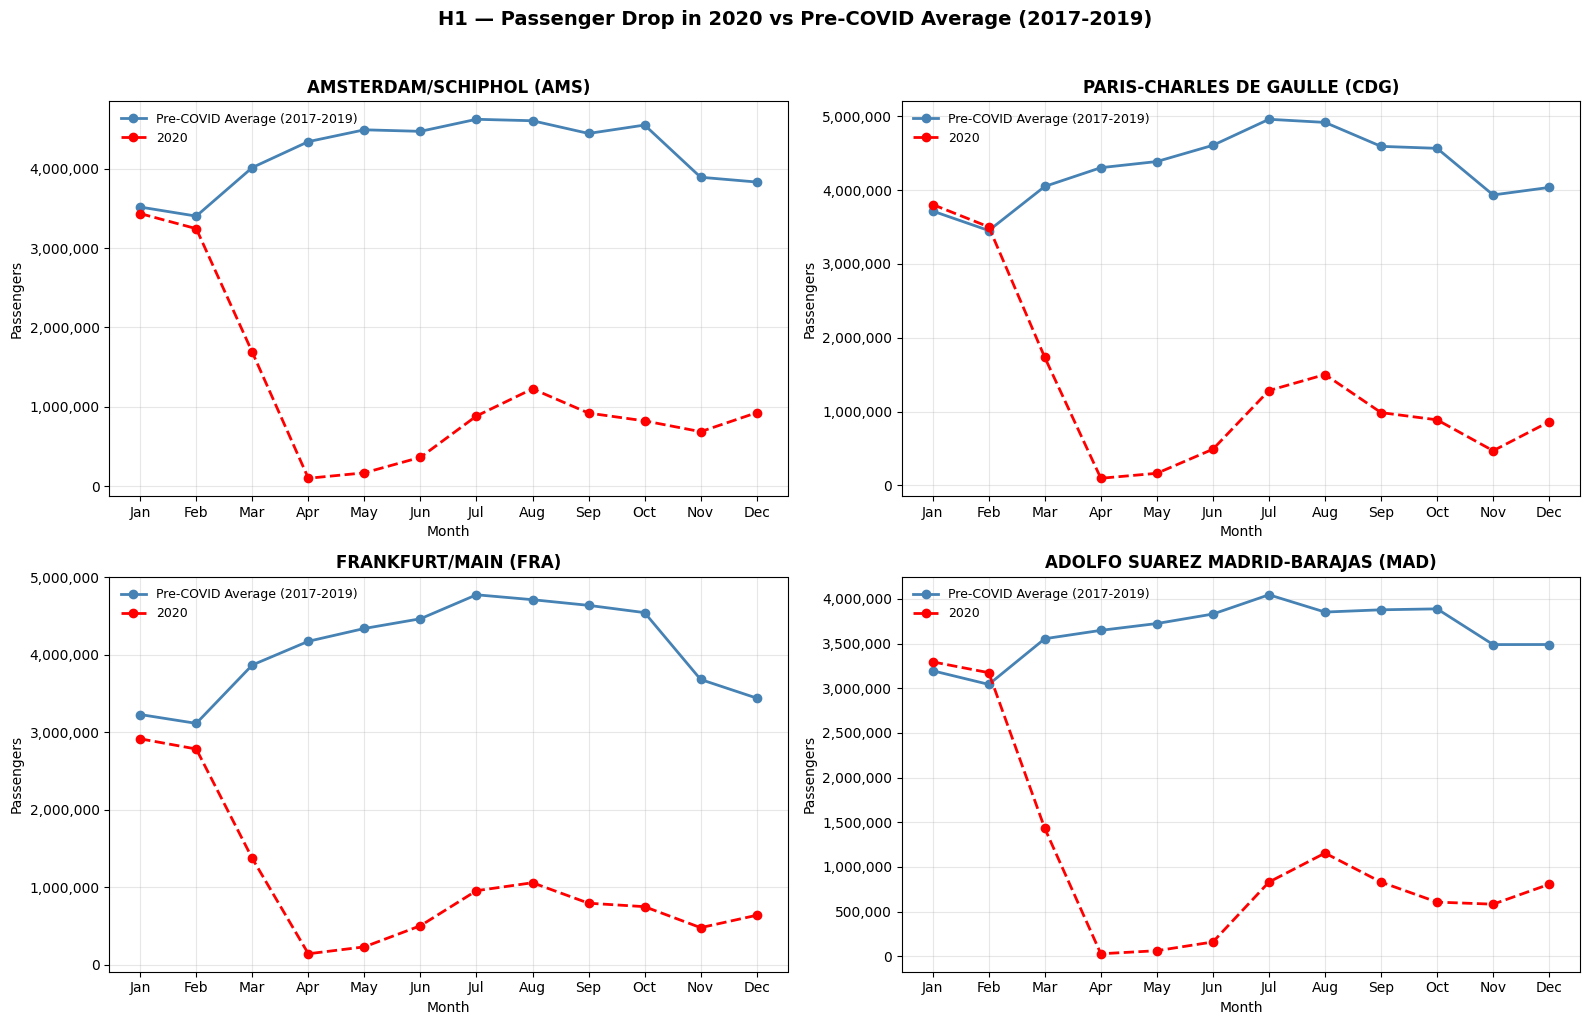

In [119]:
# Plot a line chart per airport

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, airport in enumerate(airports):
    ax = axes[i]
    
    # Baseline
    base = baseline_monthly[baseline_monthly["origin"] == airport]
    ax.plot(base["month"], base["baseline_avg"], 
            label="Pre-COVID Average (2017-2019)", 
            color="steelblue", linewidth=2, marker="o")
    
    # 2020
    cov = covid_2020_monthly[covid_2020_monthly["origin"] == airport]
    ax.plot(cov["month"], cov["passengers"], 
            label="2020", 
            color="red", linewidth=2, marker="o", linestyle="--")
    
    # 2021
    #cov21 = covid_2021_monthly[covid_2021_monthly["origin"] == airport]
    #ax.plot(cov21["month"], cov21["passengers"],
    #        label="2021",
    #        color="orange", linewidth=2, marker="o", linestyle="--")
    
    # Formatting
    
    full_name = airport.replace(" airport", "") 
    iata = labels[airport]
    ax.set_title(f"{full_name} ({iata})", fontsize=12, fontweight="bold")
    
    ax.set_xlabel("Month")
    ax.set_ylabel("Passengers")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])
    
    # Legend fixed position — upper left
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)
    ax.grid(True, alpha=0.3)

plt.suptitle("H1 — Passenger Drop in 2020 vs Pre-COVID Average (2017-2019)", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate baseline per airport
baseline_per_airport = (
    passengers_core[passengers_core["year"].isin([2017, 2018, 2019])]
    .groupby(["origin", "year"])["passengers"].sum()
    .reset_index()
    .groupby("origin")["passengers"].mean()
    .reset_index()
    .rename(columns={"passengers": "baseline"})
)

# Get 2020 totals per airport
data_2020 = (
    passengers_core[passengers_core["year"] == 2020]
    .groupby("origin")["passengers"].sum()
    .reset_index()
    .rename(columns={"passengers": "passengers_2020"})
)

# Merge and calculate drop %
plot_df = baseline_per_airport.merge(data_2020, on="origin")
plot_df["drop_pct"] = ((plot_df["passengers_2020"] - plot_df["baseline"]) / plot_df["baseline"] * 100).round(1)

# Sort by airports alphabetically
plot_df["sort_key"] = plot_df["origin"].map(labels)
plot_df = plot_df.sort_values("sort_key").reset_index(drop=True)

# x positions
x = np.arange(len(plot_df))

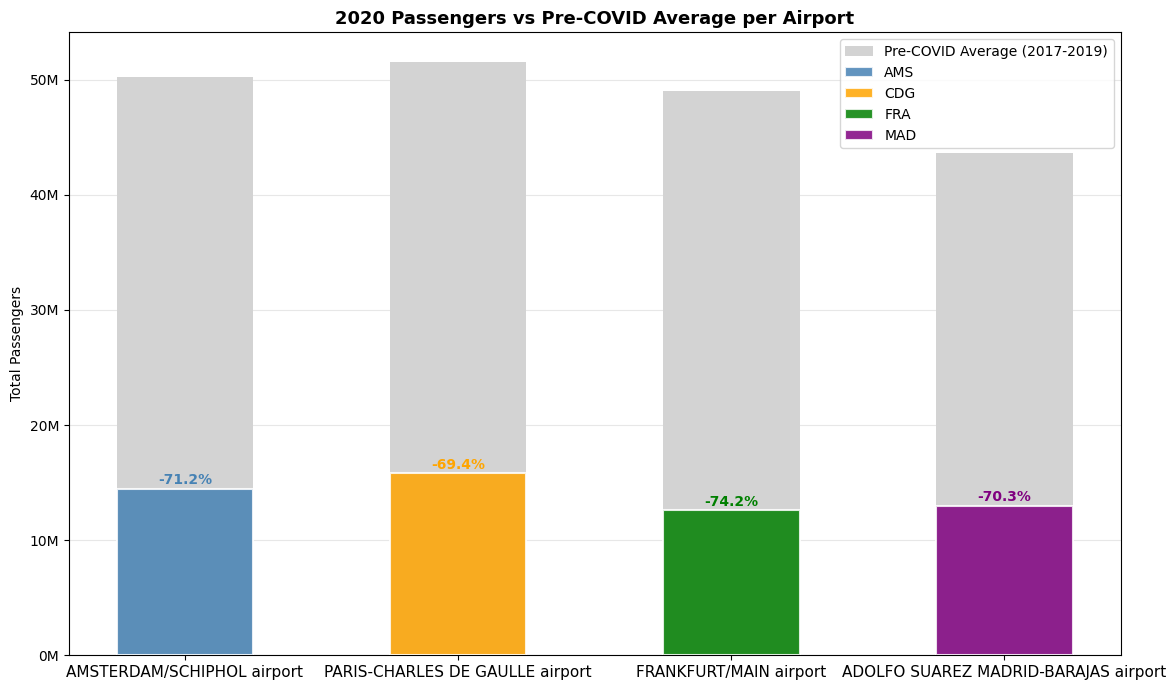

In [92]:
fig, ax = plt.subplots(figsize=(12, 7))

width = 0.5  # same width for both

# Background bars (baseline) - grey, behind
ax.bar(x, plot_df["baseline"],
       width=width,
       color="lightgrey",
       label="Pre-COVID Average (2017-2019)",
       zorder=2)

# Foreground bars (2020) - colored, in front
for i, (_, row) in enumerate(plot_df.iterrows()):
    airport = row["origin"]
    ax.bar(x[i], row["passengers_2020"],
           width=width,
           color=colors[airport],
           label=labels[airport],
           zorder=3,
           alpha=0.85,
           edgecolor="white", #small white line between bars
           linewidth=1.5)
    
    # % drop label on top of 2020 bar
    ax.text(x[i], 
        row["passengers_2020"] * 1.01,   # at the top of colored bar, 1% (of the bar hight) above
        f"{row['drop_pct']}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color=colors[airport])

# Formatting
ax.set_title("2020 Passengers vs Pre-COVID Average per Airport",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Total Passengers")
ax.set_xticks(x)
ax.set_xticklabels(labels.keys(), fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.0f}M"))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [93]:
# drop by airport pre vs 2020 and 2021
baseline_annual = passengers_core[passengers_core["year"].isin([2017,2018,2019])]
baseline_avg = baseline_annual.groupby("origin")["passengers"].sum() / 3

for year in [2020, 2021]:
    year_total = passengers_core[passengers_core["year"] == year].groupby("origin")["passengers"].sum()
    drop = ((year_total - baseline_avg) / baseline_avg * 100).round(2)
    print(f"\n{year} drop vs baseline:")
    print(drop)


2020 drop vs baseline:
origin
ADOLFO SUAREZ MADRID-BARAJAS airport   -70.29
AMSTERDAM/SCHIPHOL airport             -71.18
FRANKFURT/MAIN airport                 -74.23
PARIS-CHARLES DE GAULLE airport        -69.35
Name: passengers, dtype: Float64

2021 drop vs baseline:
origin
ADOLFO SUAREZ MADRID-BARAJAS airport   -54.17
AMSTERDAM/SCHIPHOL airport             -62.33
FRANKFURT/MAIN airport                 -61.35
PARIS-CHARLES DE GAULLE airport         -60.0
Name: passengers, dtype: Float64


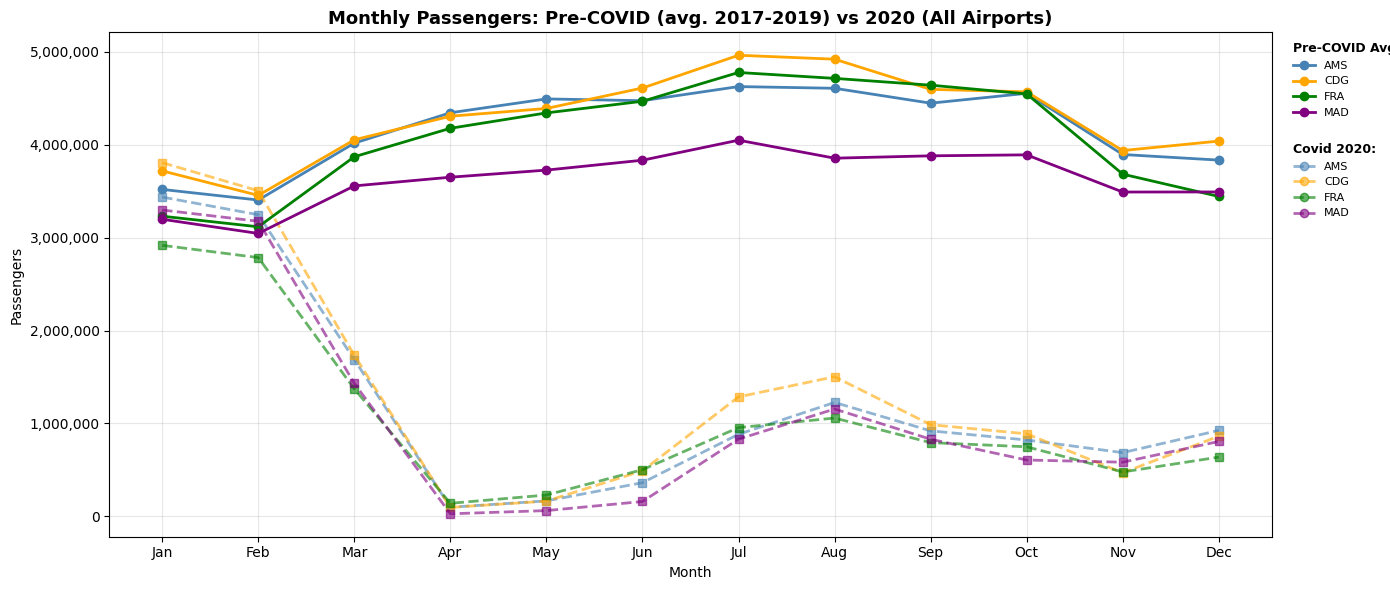

In [94]:
# Passengers by airport and month (Pre-Covid avg - 2020 - 2021)
fig, ax = plt.subplots(figsize=(14, 6))

for airport in airports:
    # Baseline
    base = baseline_monthly[baseline_monthly["origin"] == airport]
    ax.plot(base["month"], base["baseline_avg"],
            color=colors[airport], linewidth=2, marker="o",
            label=f"{labels[airport]} Pre-COVID avg")
    
    # 2020
    cov20 = covid_2020_monthly[covid_2020_monthly["origin"] == airport]
    ax.plot(cov20["month"], cov20["passengers"],
            color=colors[airport], linewidth=2, marker="s",
            linestyle="--", alpha=0.6,
            label=f"{labels[airport]} 2020")
    
    # 2021
    #cov21 = covid_2021_monthly[covid_2021_monthly["origin"] == airport]
    #ax.plot(cov21["month"], cov21["passengers"],
    #        color=colors[airport], linewidth=2, marker="s",
    #        linestyle=":", alpha=0.4,
    #        label=f"{labels[airport]} 2021")

    # Pre-COVID avg entries — solid lines
    leg1_entries = [
        mlines.Line2D([], [], color=colors[airport], linewidth=2, 
                  marker="o", linestyle="-",
                  label=labels[airport])
        for airport in labels.keys()
    ]   

    # 2020 entries — dashed lines
    leg2_entries = [
        mlines.Line2D([], [], color=colors[airport], linewidth=2,
                    marker="o", linestyle="--", alpha=0.6,
                    label=labels[airport])
        for airport in labels.keys()
    ]

ax.set_title("Monthly Passengers: Pre-COVID (avg. 2017-2019) vs 2020 (All Airports)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Legend 1 - Pre-COVID
leg1 = ax.legend(
    handles=leg1_entries,
    title="Pre-COVID Avg:",
    title_fontproperties={"weight": "bold", "size": 9},
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    frameon=False,
    handlelength=2, 
    alignment="left"
)
ax.add_artist(leg1)

# Legend 2 - 2020
leg2 = ax.legend(
    handles=leg2_entries,
    title="Covid 2020:",
    title_fontproperties={"weight": "bold", "size": 9},
    bbox_to_anchor=(1.01, 0.80),
    loc="upper left",
    fontsize=8,
    frameon=False,
    handlelength=2,
    alignment="left"
)



ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

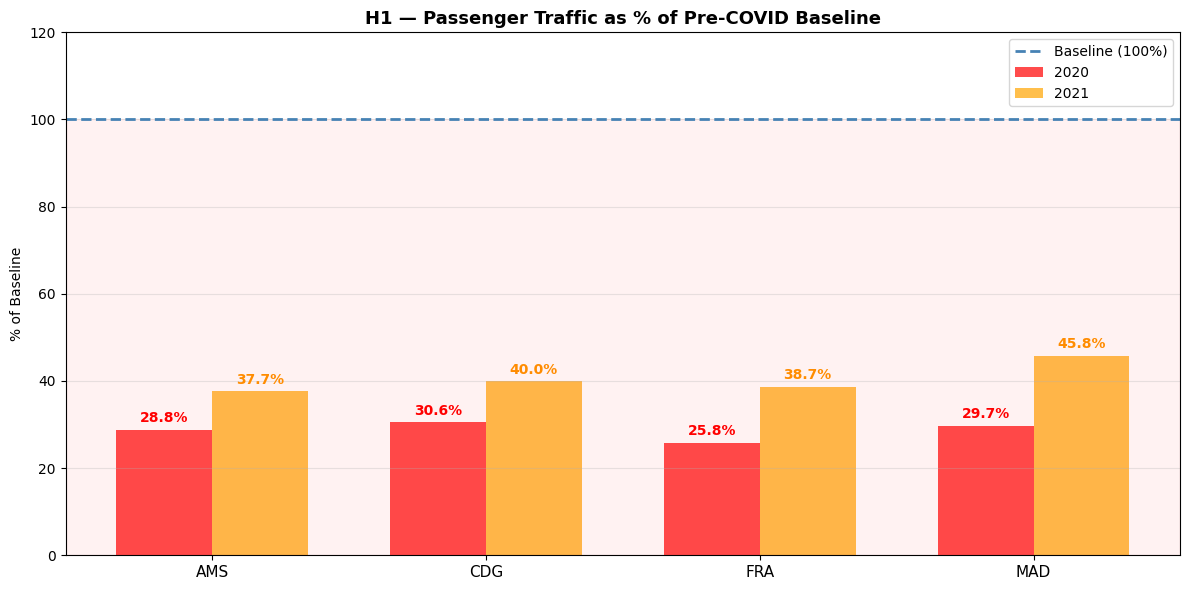

In [95]:
# Bar plot - annual % per airport vs baseline
# Calculate % of baseline for each airport
baseline_annual = passengers_core[passengers_core["year"].isin([2017, 2018, 2019])]
baseline_avg_annual = baseline_annual.groupby("origin")["passengers"].sum() / 3

pct_data = []
for airport in airports:
    base = baseline_avg_annual[airport]
    for year in [2020, 2021]:
        total = passengers_core[
            (passengers_core["origin"] == airport) & 
            (passengers_core["year"] == year)
        ]["passengers"].sum()
        pct = (total / base * 100).round(1)
        pct_data.append({
            "airport": labels[airport],
            "year": year,
            "pct_of_baseline": pct
        })

pct_df = pd.DataFrame(pct_data)

# Plot paired bars
fig, ax = plt.subplots(figsize=(12, 6))

airport_labels = [labels[a] for a in airports]
x = np.arange(len(airport_labels))
width = 0.35

bars_2020 = ax.bar(x - width/2, 
                    pct_df[pct_df["year"] == 2020]["pct_of_baseline"],
                    width, label="2020", color="red", alpha=0.7)

bars_2021 = ax.bar(x + width/2, 
                    pct_df[pct_df["year"] == 2021]["pct_of_baseline"],
                    width, label="2021", color="orange", alpha=0.7)

# Baseline reference line at 100%
ax.axhline(y=100, color="steelblue", linewidth=2, 
           linestyle="--", label="Baseline (100%)")

# Add % labels on bars
for bar in bars_2020:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", 
            fontsize=10, fontweight="bold", color="red")

for bar in bars_2021:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="darkorange")

ax.set_title("H1 — Passenger Traffic as % of Pre-COVID Baseline",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% of Baseline")
ax.set_xticks(x)
ax.set_xticklabels(airport_labels, fontsize=11)
ax.set_ylim(0, 120)
ax.axhspan(0, 100, alpha=0.05, color="red")  # red zone below baseline
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [96]:
# Compare monthly passengers: baseline vs 2020
baseline_monthly = passengers_core[
    passengers_core["year"].isin([2017, 2018, 2019])
]["passengers"].dropna()

covid_monthly = passengers_core[
    passengers_core["year"] == 2020
]["passengers"].dropna()

t_stat, p_value = stats.ttest_ind(baseline_monthly, covid_monthly)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significant: {p_value < 0.05}")

T-statistic: 48.9458
P-value: 0.000000
Significant: True


"The COVID-19 impact on passenger traffic was statistically significant (p ≈ 0), with a ~70% drop in 2020. Cargo traffic, while showing a ~25% decline, did not show statistically significant changes — remaining within normal operational variation throughout the pandemic period."

"To test whether the drop was specific to passenger travel or affected aviation broadly, we applied the same analysis to cargo traffic. While passenger traffic showed an extremely significant drop (p ≈ 0), cargo traffic remained within normal variation (p = 0.28) — confirming that COVID-19 specifically disrupted passenger demand while cargo operations proved resilient"

### 5.2.3 Conclusion

Passenger traffic across all four hub airports dropped dramatically in 2020, with an average decline of approximately 70% compared to the 2017-2019 Pre-COVID avg, taken as reference. Frankfurt (FRA) experienced the steepest drop at 74.2%, followed by Amsterdam (AMS) at 71.2%, Madrid (MAD) at 70.3% and Paris CDG at 69.4%. The drop was confirmed statistically significant (t-test, p ≈ 0), with the sharpest decline occurring in April 2020 following the imposition of travel restrictions across Europe. By 2021 traffic had partially recovered but remained approximately 60-65% below pre-COVID levels."

## 5.3 H2 - AMS Passengers Traffic recovered the slowest by 2022

### 5.3.1 Hypotheis Analysis and Plotting

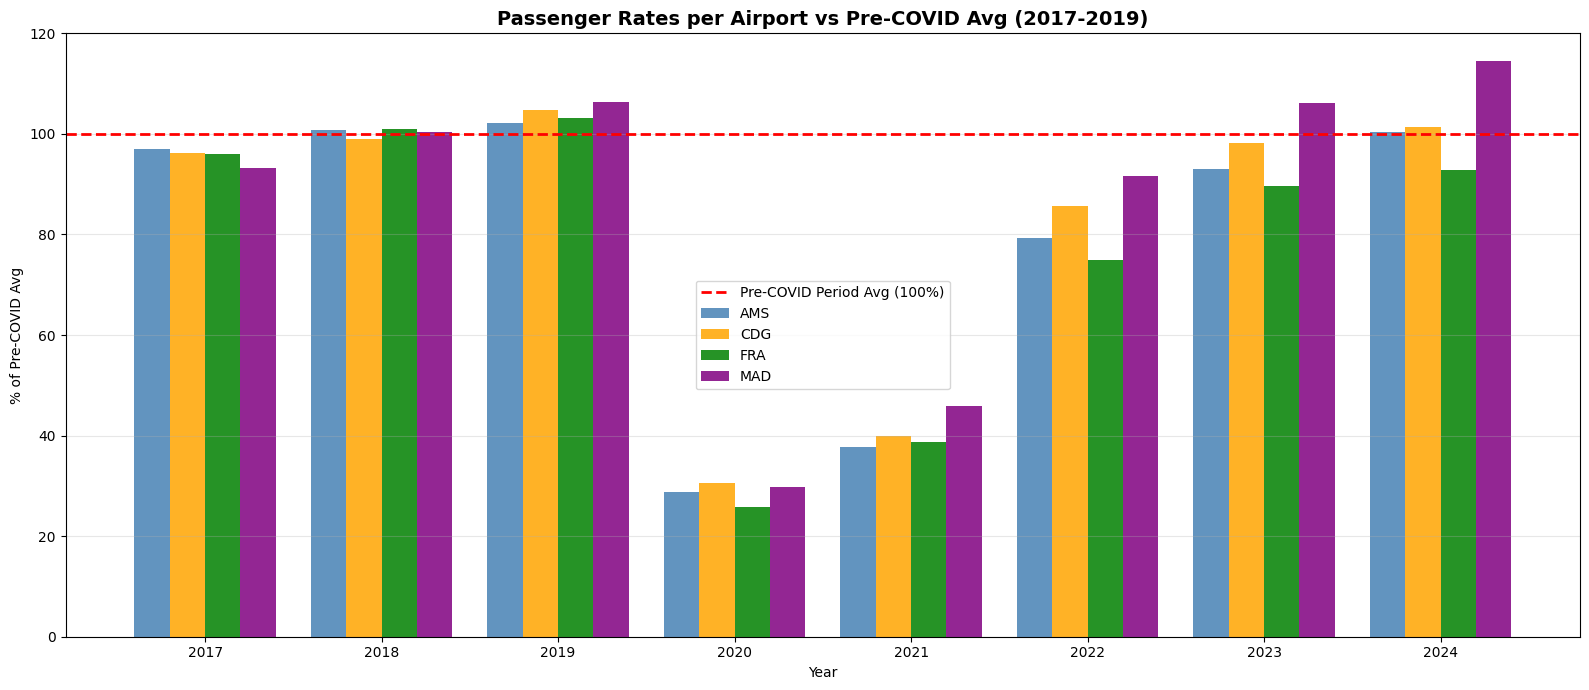


Recovery Rate % per Airport per Year:
year   2017    2018    2019   2020   2021   2022   2023    2024
MAD   93.24  100.34  106.42  29.71  45.83  91.64  106.1   114.4
AMS   96.99  100.87  102.14  28.82  37.67   79.3   93.0  100.28
FRA   95.93  100.95  103.13  25.77  38.65  74.94  89.66   92.88
CDG   96.12   99.07  104.81  30.65   40.0  85.62  98.18  101.45


In [124]:
# ─────────────────────────────────────────────
# PLOT — Passengers Rates per airport per year vs Pre-COVID Avg
# ─────────────────────────────────────────────
years = sorted(passengers_core["year"].unique())
x = np.arange(len(years))
width = 0.2

colors = {
    "AMSTERDAM/SCHIPHOL airport": "steelblue",
    "FRANKFURT/MAIN airport": "green",
    "ADOLFO SUAREZ MADRID-BARAJAS airport": "purple",
    "PARIS-CHARLES DE GAULLE airport": "orange"
}

fig, ax = plt.subplots(figsize=(16, 7))

for i, airport in enumerate(airports):
    data = yearly[yearly["origin"] == airport].sort_values("year")
    bars = ax.bar(
        x + i * width,
        data["pct_of_baseline"],
        width,
        label=labels[airport],
        color=colors[airport],
        alpha=0.85
    )

# Threshold line at 100%
ax.axhline(y=100, color="red", linewidth=2, linestyle="--", label="Pre-COVID Period Avg (100%)")

# Formatting
ax.set_title("Passenger Rates per Airport vs Pre-COVID Avg (2017-2019)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% of Pre-COVID Avg")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(years)
ax.set_ylim(0, 120)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# PRINT SUMMARY TABLE
# ─────────────────────────────────────────────
pivot = yearly.pivot(index="origin", columns="year", values="pct_of_baseline")
pivot.index = [labels[a] for a in pivot.index]
print("\nRecovery Rate % per Airport per Year:")
print(pivot.round(2).to_string())

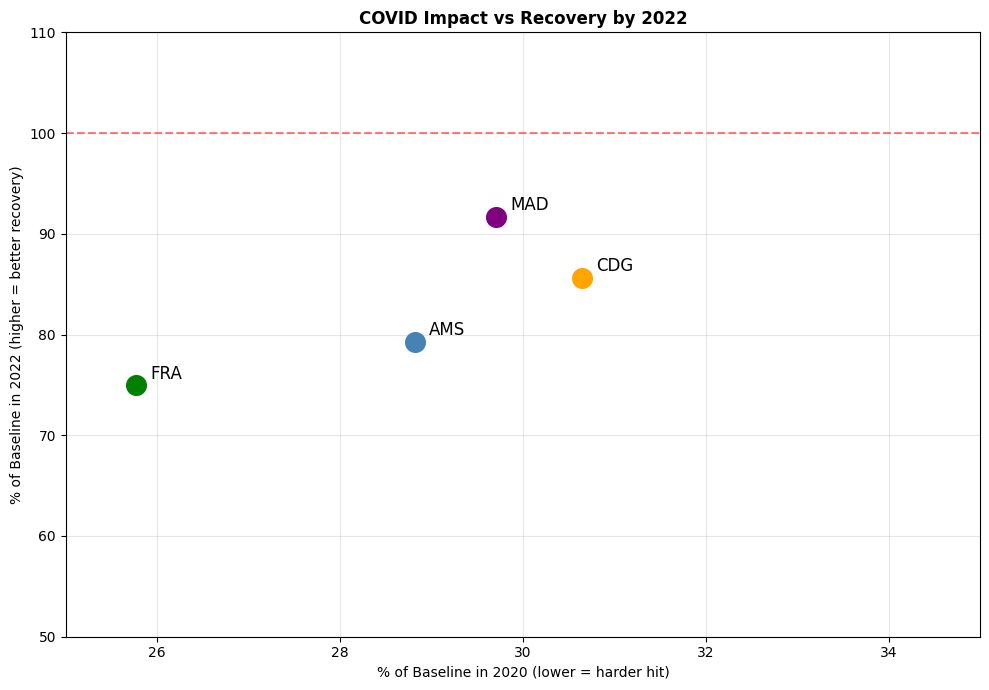

In [ ]:
# ─────────────────────────────────────────────
# PLOT — scatter plot - Covid Impact vs Recovery 2022 
# ─────────────────────────────────────────────
drop_2020 = yearly[yearly["year"] == 2020][["origin", "pct_of_baseline"]]\
    .rename(columns={"pct_of_baseline": "drop_2020"})
recovery_2022= yearly[yearly["year"] == 2022][["origin", "pct_of_baseline"]]\
    .rename(columns={"pct_of_baseline": "recovery_2022"})

scatter_df = drop_2020.merge(recovery_2022, on="origin")

fig, ax = plt.subplots(figsize=(10, 7))
for _, row in scatter_df.iterrows():
    ax.scatter(row["drop_2020"], row["recovery_2022"],
               color=colors[row["origin"]], s=200, zorder=5)
    ax.annotate(labels[row["origin"]],
                (row["drop_2020"], row["recovery_2022"]),
                textcoords="offset points", xytext=(10, 5), fontsize=12)

ax.axhline(y=100, color="red", linestyle="--", alpha=0.5, label="Baseline recovery")
ax.set_xlabel("% of Baseline in 2020 (lower = harder hit)")
ax.set_ylabel("% of Baseline in 2022 (higher = better recovery)")
ax.set_title("COVID Impact vs Recovery by 2022", fontweight="bold")
ax.set_xlim(25, 35)  # zoom x axis
ax.set_ylim(50, 110)  # zoom y axis
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

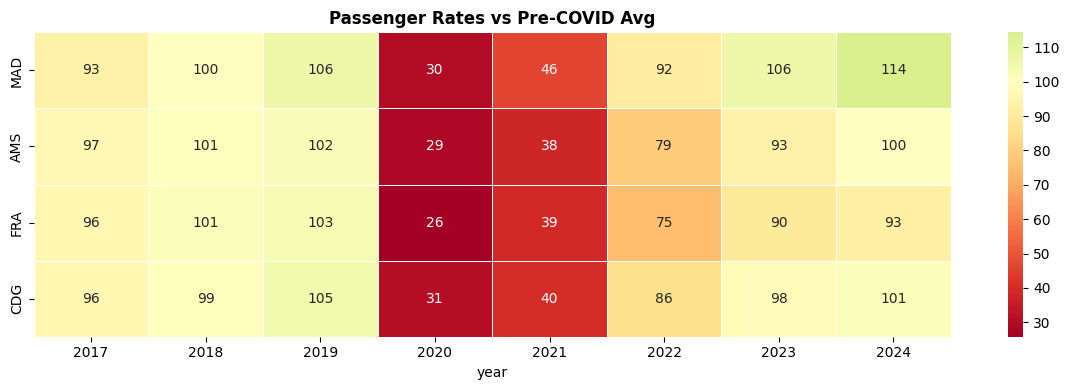

In [126]:
# ─────────────────────────────────────────────
# PLOT — Heatmap - Passengers Rates per airport per year vs Pre-COVID Avg
# ─────────────────────────────────────────────

pivot = yearly.pivot(index="origin", columns="year", values="pct_of_baseline")
pivot.index = [labels[a] for a in pivot.index]

pivot = pivot.astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, 
            annot=True, fmt=".0f",
            cmap="RdYlGn",  # red=low, yellow=medium, green=recovered
            center=100,
            linewidths=0.5,
            ax=ax)
ax.set_title("Passenger Rates vs Pre-COVID Avg", fontweight="bold")
plt.tight_layout()
plt.show()

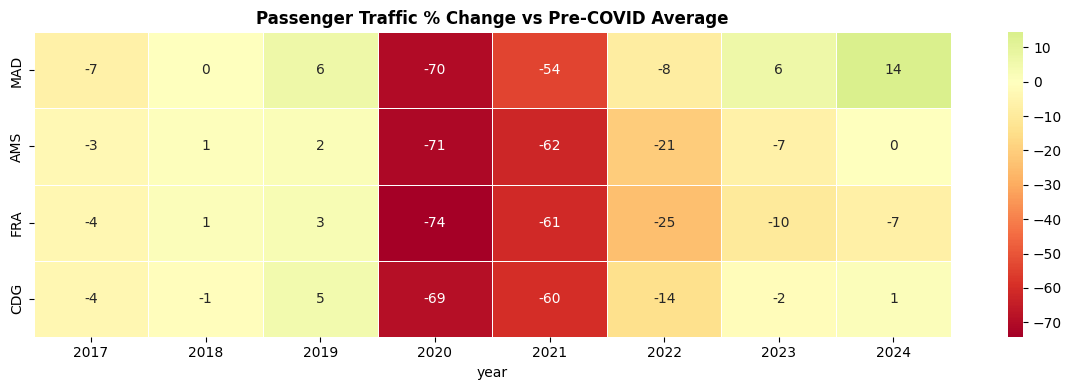

In [ ]:
# ─────────────────────────────────────────────
# PLOT — Heatmap - Passengers Traffic % Changes per airport per year vs Pre-COVID Avg
# ─────────────────────────────────────────────
pivot = yearly.pivot(index="origin", columns="year", values="drop_pct")
pivot.index = [labels[a] for a in pivot.index]
pivot = pivot.astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot,
            annot=True, fmt=".0f",
            cmap="RdYlGn",
            center=0,        # ← center at 0% now, not 100%
            linewidths=0.5,
            ax=ax)
ax.set_title("Passenger Traffic % Change vs Pre-COVID Average", fontweight="bold")
plt.tight_layout()
plt.show()

In [128]:
# ─────────────────────────────────────────────
# Summary - Passengers Traffic Recovery Indexes
# ─────────────────────────────────────────────
# Recovery Index Table
recovery_index = yearly[["origin", "year", "pct_of_baseline"]].copy()
recovery_index["origin"] = recovery_index["origin"].map(labels)

# Pivot to wide format
recovery_table = recovery_index.pivot(
    index="origin", 
    columns="year", 
    values="pct_of_baseline"
)

# Add average pre-COVID column
precovid_avg = recovery_table[[2017, 2018, 2019]].mean(axis=1).round(2)
recovery_table.insert(0, "Pre-COVID Avg", precovid_avg)

# Drop 2017-2019 columns — keep only avg + COVID + post-COVID
recovery_table = recovery_table.drop(columns=[2017, 2018, 2019])

# Sort by airport_order
recovery_table = recovery_table.loc[[labels[a] for a in airport_order]]

# Format nicely
recovery_table = recovery_table.round(1)
recovery_table.columns.name = None
recovery_table.index.name = "Airport"

print("Recovery Index (% of Pre-COVID Average):")
print("=" * 55)
print(recovery_table.to_string())
print("=" * 55)
print("Note: 100% = Pre-COVID baseline level")
print("      >100% = Exceeded pre-COVID levels")
print("      <100% = Below pre-COVID levels")

Recovery Index (% of Pre-COVID Average):
         Pre-COVID Avg  2020  2021  2022   2023   2024
Airport                                               
AMS              100.0  28.8  37.7  79.3   93.0  100.3
CDG              100.0  30.6  40.0  85.6   98.2  101.4
FRA              100.0  25.8  38.6  74.9   89.7   92.9
MAD              100.0  29.7  45.8  91.6  106.1  114.4
Note: 100% = Pre-COVID baseline level
      >100% = Exceeded pre-COVID levels
      <100% = Below pre-COVID levels


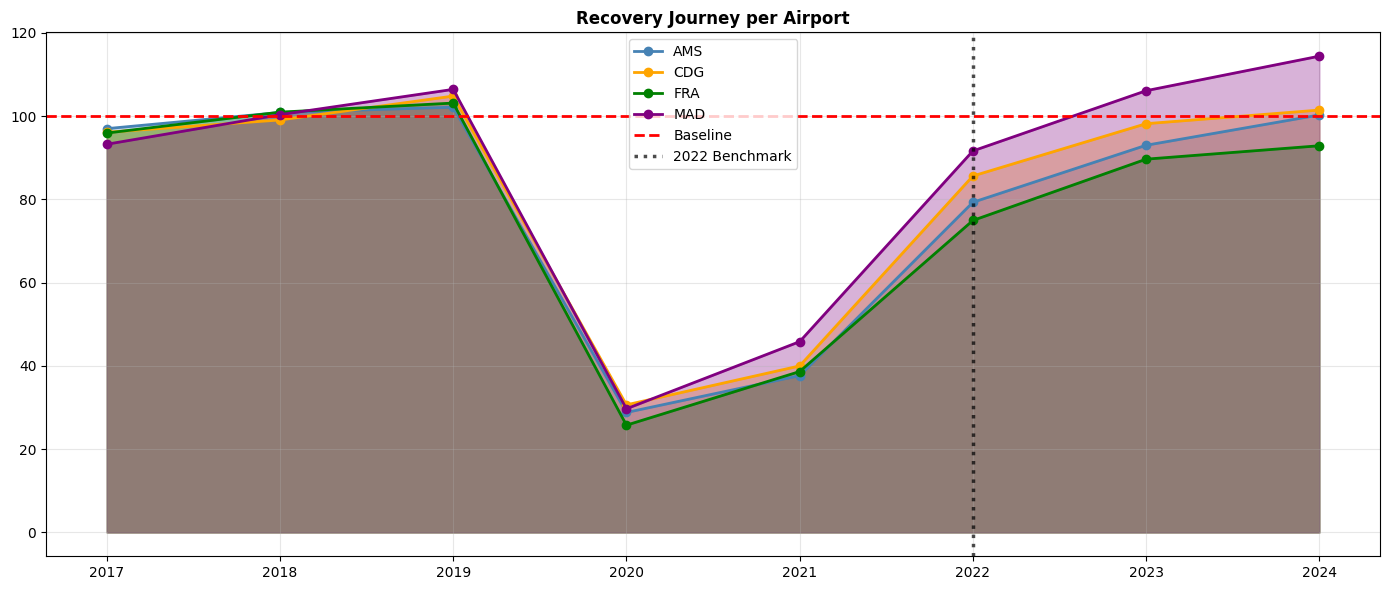

In [ ]:
# ─────────────────────────────────────────────
# Plot - Area -  Recovery Journey per Airport (2017-2024) (see below - nicer version)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

for airport in labels.keys():
    data = yearly[yearly["origin"] == airport].sort_values("year")
    ax.fill_between(data["year"], data["pct_of_baseline"],
                    alpha=0.3, color=colors[airport])
    ax.plot(data["year"], data["pct_of_baseline"],
            color=colors[airport], linewidth=2,
            marker="o", label=labels[airport])

ax.axhline(y=100, color="red", linewidth=2, linestyle="--", label="Baseline")
ax.axvline(x=2022, color="black", linewidth=2.5, 
           linestyle=":", alpha=0.7, label="2022 Benchmark")
ax.set_title("Recovery Journey per Airport", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Airport Pre-COVID Avg      COVID Avg           2022 Recovery
    AMS         50.2M 16.7M (-66.8%) 39.8M (-20.7%)  +46.1pp
    CDG         51.5M 18.2M (-64.7%) 44.1M (-14.4%)  +50.3pp
    FRA         49.0M 15.8M (-67.8%) 36.7M (-25.1%)  +42.7pp
    MAD         43.6M 16.5M (-62.2%)  40.0M (-8.4%)  +53.9pp


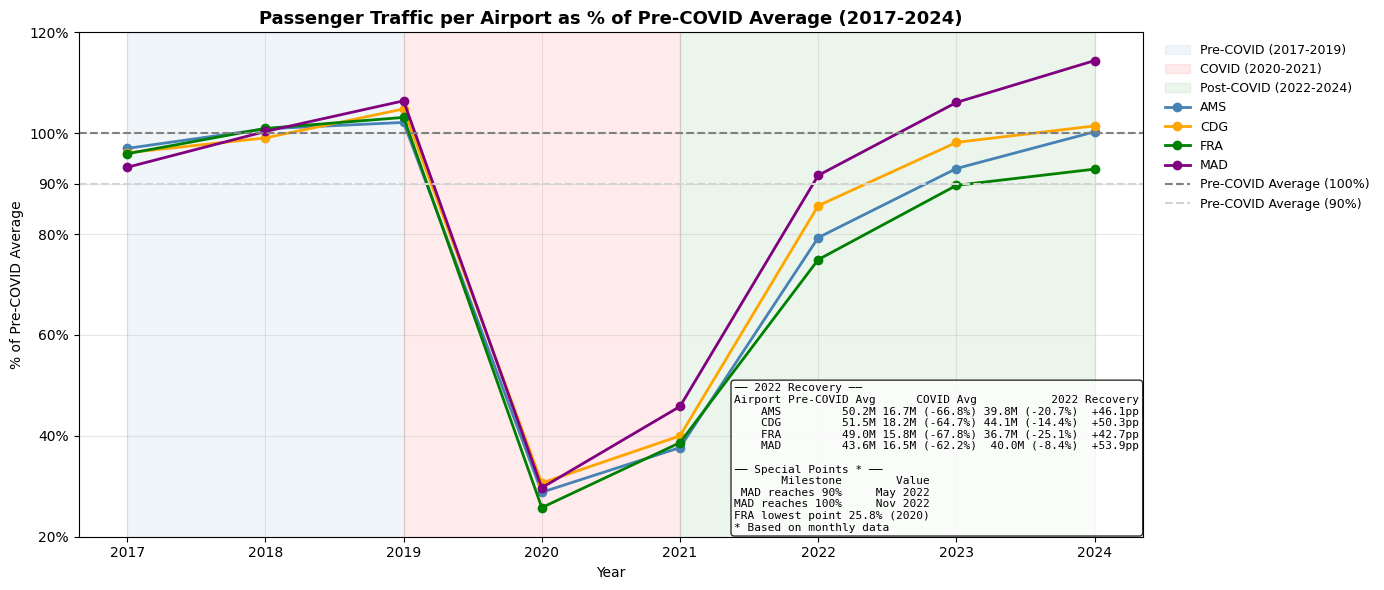

In [156]:
# ─────────────────────────────────────────────
# Plot - v2 of the Area plot - much nicer 
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# ── PERIOD SHADINGS ──────────────────────────────
ax.axvspan(2017, 2019, alpha=0.08, color="steelblue", label="Pre-COVID (2017-2019)")
ax.axvspan(2019, 2021, alpha=0.08, color="red", label="COVID (2020-2021)")
ax.axvspan(2021, 2024, alpha=0.08, color="green", label="Post-COVID (2022-2024)")

# ── LINES ────────────────────────────────────────
for airport in labels.keys():
    data = yearly[yearly["origin"] == airport].sort_values("year")
    ax.plot(data["year"], data["pct_of_baseline"],
            color=colors[airport], linewidth=2,
            marker="o", label=labels[airport])

# ── BASELINE ─────────────────────────────────────
ax.axhline(y=100, color="grey", linewidth=1.5, 
           linestyle="--", label="Pre-COVID Average (100%)")

ax.axhline(y=90, color="lightgrey", linewidth=1.5, 
           linestyle="--", label="Pre-COVID Average (90%)")

# ── Summary ─────────────────────────────────────
# Summary Table - Section 1 - 2022 Recovery (H2)
# Pre-COVID avg per airport
precovid = yearly[yearly["year"].isin([2017, 2018, 2019])].groupby("origin").agg(
    precovid_pax=("passengers", "mean"),
    baseline=("baseline", "first")
).reset_index()

# COVID avg per airport (2020-2021)
covid_avg = yearly[yearly["year"].isin([2020, 2021])].groupby("origin").agg(
    covid_pax=("passengers", "mean"),
    covid_pct=("pct_of_baseline", "mean")
).reset_index()

# 2022
year_2022 = yearly[yearly["year"] == 2022][["origin", "passengers", "pct_of_baseline"]].copy()

# Merge all
result = precovid.merge(covid_avg, on="origin").merge(year_2022, on="origin")
result["origin"] = result["origin"].map(labels)
result["recovery"] = (result["pct_of_baseline"] - result["covid_pct"]).round(1)

# Format
result["Pre-COVID Avg"] = (result["precovid_pax"] / 1_000_000).round(1).astype(str) + "M"
result["COVID Avg"] = (result["covid_pax"] / 1_000_000).round(1).astype(str) + "M (" + (result["covid_pct"] - 100).round(1).astype(str) + "%)"
result["2022"] = (result["passengers"] / 1_000_000).round(1).astype(str) + "M (" + (result["pct_of_baseline"] - 100).round(1).astype(str) + "%)"
result["Recovery"] = result["recovery"].apply(lambda x: f"+{x:.1f}pp")

result = result[["origin", "Pre-COVID Avg", "COVID Avg", "2022", "Recovery"]]\
    .rename(columns={"origin": "Airport"})\
    .sort_values("Airport")

print(result.to_string(index=False))

# Summary Table - Section 2 - Special points
special_points = pd.DataFrame({
    "Milestone": [
        "MAD reaches 90%",
        "MAD reaches 100%",
        "FRA lowest point"
    ],
    "Value": [
        f"{month_names[int(mad_reach['month'])]} {int(mad_reach['year'])}",
        f"{month_names[int(mad_cross['month'])]} {int(mad_cross['year'])}",
        f"{fra_min['pct_of_baseline']:.1f}% ({int(fra_min['year'])})"
    ]
})

# Combine into one annotation
table_text = (
    "── 2022 Recovery ──\n" +
    result.to_string(index=False) +
    "\n\n── Special Points * ──\n" +
    special_points.to_string(index=False) +
    "\n* Based on monthly data"
)

ax.annotate(
    table_text,
    xy=(0.616, 0.008),
    xycoords="axes fraction",
    fontsize=8,
    ha="left",
    va="bottom",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

# ── FORMATTING ───────────────────────────────────

ax.set_title("Passenger Traffic per Airport as % of Pre-COVID Average (2017-2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% of Pre-COVID Average")
ax.set_xlabel("Year")
ax.set_xticks(yearly["year"].unique())
ax.set_yticks([20, 40, 60, 80, 90, 100, 120])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", 
          fontsize=9, frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.show()

### 5.3.2 Conclusion

Contrary to the initial hypothesis, Amsterdam (AMS) was not the slowest recovering airport by 2022. The data reveals that Frankfurt (FRA) showed the weakest recovery, reaching only 75% of pre-COVID passenger levels by 2022 — the lowest of all four hubs. Madrid (MAD) demonstrated the strongest recovery at 92%, followed by Paris CDG at 86% and Amsterdam AMS at 79%.
FRA's slower recovery can be attributed to its heavy dependence on business travel — a segment that recovered significantly slower than leisure travel post-COVID. Lufthansa's post-COVID restructuring may also have contributed to reduced capacity at Frankfurt.
Madrid's exceptional recovery reflects Spain's strong tourism rebound — pent-up leisure demand drove passenger numbers back quickly, and by 2024 MAD had exceeded pre-COVID levels  by 14% 
 — the only airport in our study to do so by a significant margin.
H2 is therefore rejected — FRA, not AMS, recovered the slowest by 2022.

# 5.4 H3 - Efficiency (Passengers per flight) dropped in 2020 and recovered by 2024

### 5.4.1 Data Calculations

In [166]:
# Definition of new df: passengers_core with only rows where passengers and flights are not null and flights > 0. 
efficiency = passengers_core[
    passengers_core["passengers"].notna() &
    passengers_core["flights"].notna() &
    (passengers_core["flights"] > 0)
].copy()

# Calculate passengers per flight
efficiency["pax_per_flight"] = (efficiency["passengers"] / efficiency["flights"]).round(1)

In [ ]:
# Calculate yearly efficiency per airport by aggregating passengers and flights (more accurate than averaging pax_per_flight)
efficiency_yearly = (
    efficiency.groupby(["origin", "year"])
    .agg(
        total_passengers=("passengers", "sum"),
        total_flights=("flights", "sum")
    )
    .reset_index()
)

efficiency_yearly["pax_per_flight"] = (
    efficiency_yearly["total_passengers"] / efficiency_yearly["total_flights"]
).round(1)

In [174]:
# ─────────────────────────────────────────────
# H3 DATA PREPARATION
# ─────────────────────────────────────────────

# Filter for efficiency analysis
efficiency = passengers_core[
    passengers_core["passengers"].notna() &
    passengers_core["flights"].notna() &
    (passengers_core["flights"] > 0)
].copy()
efficiency["pax_per_flight"] = (efficiency["passengers"] / efficiency["flights"]).round(1)

# Yearly efficiency per airport
efficiency_yearly = (
    efficiency.groupby(["origin", "year"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
efficiency_yearly["pax_per_flight"] = (
    efficiency_yearly["total_pax"] / efficiency_yearly["total_flights"]
).round(1)

# Efficiency baseline (avg 2017-2019)
efficiency_annual_baseline = (
    efficiency_yearly[efficiency_yearly["year"].isin([2017, 2018, 2019])]
    .groupby("origin")["pax_per_flight"].mean()
    .reset_index()
    .rename(columns={"pax_per_flight": "baseline_eff"})
)

# Merge and calculate % change for ALL years
efficiency_yearly = efficiency_yearly.merge(efficiency_annual_baseline, on="origin")
efficiency_yearly["pct_change"] = (
    (efficiency_yearly["pax_per_flight"] - efficiency_yearly["baseline_eff"]) /
    efficiency_yearly["baseline_eff"] * 100
).round(1)

# ← THIS IS WHAT YOU LOST — filter for bar chart years
eff_plot_df = efficiency_yearly[
    efficiency_yearly["year"].isin([2020, 2024])  # ← updated to 2024
].copy()

# Monthly efficiency baseline
baseline_eff = (
    efficiency[efficiency["year"].isin([2017, 2018, 2019])]
    .groupby(["origin", "year", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
baseline_eff["pax_per_flight"] = baseline_eff["total_pax"] / baseline_eff["total_flights"]

baseline_eff_monthly = (
    baseline_eff.groupby(["origin", "month"])["pax_per_flight"]
    .mean()
    .reset_index()
    .rename(columns={"pax_per_flight": "baseline_avg"})
)

# Monthly efficiency for specific years
eff_2020 = (
    efficiency[efficiency["year"] == 2020]
    .groupby(["origin", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
eff_2020["pax_per_flight"] = eff_2020["total_pax"] / eff_2020["total_flights"]

eff_2024 = (
    efficiency[efficiency["year"] == 2024]
    .groupby(["origin", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
eff_2024["pax_per_flight"] = eff_2024["total_pax"] / eff_2024["total_flights"]

print("✓ H3 data preparation complete!")

✓ H3 data preparation complete!


In [167]:
# Efficiency baseline (avg 2017-2019)
efficiency_annual_baseline = (
    efficiency_yearly[efficiency_yearly["year"].isin([2017, 2018, 2019])]
    .groupby("origin")["pax_per_flight"].mean()
    .reset_index()
    .rename(columns={"pax_per_flight": "baseline_eff"})
)

# Merge and calculate % change for ALL years
efficiency_yearly = efficiency_yearly.merge(efficiency_annual_baseline, on="origin")
efficiency_yearly["pct_change"] = (
    (efficiency_yearly["pax_per_flight"] - efficiency_yearly["baseline_eff"]) /
    efficiency_yearly["baseline_eff"] * 100
).round(1)


eff_plot_df = efficiency_yearly[
    efficiency_yearly["year"].isin([2020, 2024]) 
].copy()


# Monthly baseline efficiency (avg 2017-2019) per airport
baseline_eff = (
    efficiency[efficiency["year"].isin([2017, 2018, 2019])]
    .groupby(["origin", "year", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
baseline_eff["pax_per_flight"] = baseline_eff["total_pax"] / baseline_eff["total_flights"]

# Average across 3 years per airport per month
baseline_eff_monthly = (
    baseline_eff.groupby(["origin", "month"])["pax_per_flight"]
    .mean()
    .reset_index()
    .rename(columns={"pax_per_flight": "baseline_avg"})
)

# 2020 monthly efficiency per airport
eff_2020 = (
    efficiency[efficiency["year"] == 2020]
    .groupby(["origin", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
eff_2020["pax_per_flight"] = eff_2020["total_pax"] / eff_2020["total_flights"]

# 2024 monthly efficiency per airport
eff_2024 = (
    efficiency[efficiency["year"] == 2024]
    .groupby(["origin", "month"])
    .agg(total_pax=("passengers", "sum"), total_flights=("flights", "sum"))
    .reset_index()
)
eff_2024["pax_per_flight"] = eff_2024["total_pax"] / eff_2024["total_flights"]

### 5.4.2 Hypothesis Analysis and Plotting

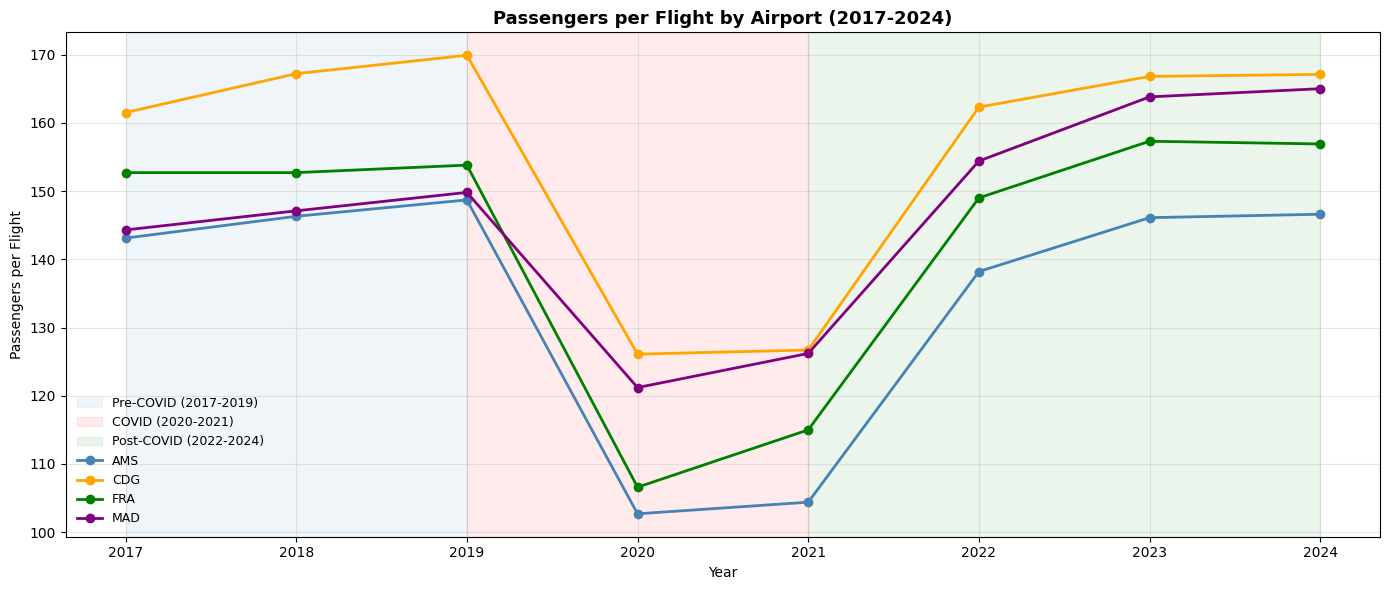

In [175]:
# Line plot showing passengers per flight by airport over the years
fig, ax = plt.subplots(figsize=(14, 6))

# Period shadings
ax.axvspan(2017, 2019, alpha=0.08, color="steelblue", label="Pre-COVID (2017-2019)")
ax.axvspan(2019, 2021, alpha=0.08, color="red", label="COVID (2020-2021)")
ax.axvspan(2021, 2024, alpha=0.08, color="green", label="Post-COVID (2022-2024)")

for airport in airports:
    data = efficiency_yearly[efficiency_yearly["origin"] == airport].sort_values("year")
    ax.plot(data["year"], data["pax_per_flight"],
            color=colors[airport], linewidth=2,
            marker="o", label=labels[airport])

ax.set_title("Passengers per Flight by Airport (2017-2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Passengers per Flight")
ax.set_xlabel("Year")
ax.set_xticks(efficiency_yearly["year"].unique())
ax.legend(frameon=False, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

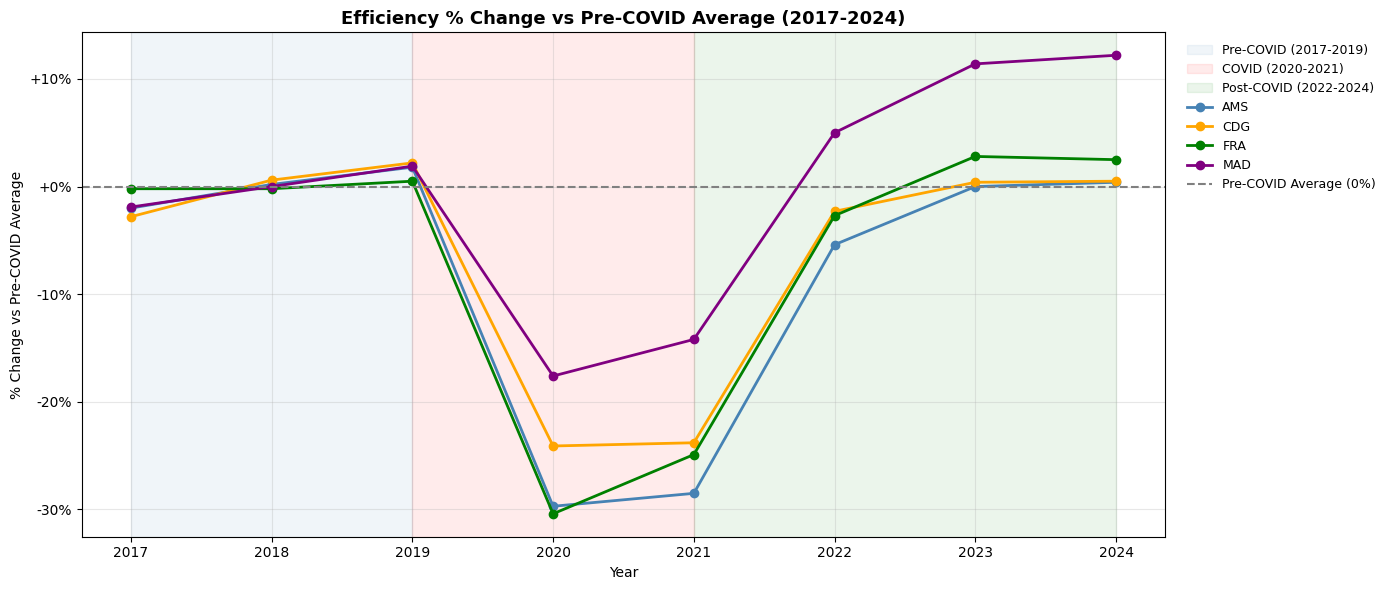

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Period shadings
ax.axvspan(2017, 2019, alpha=0.08, color="steelblue", label="Pre-COVID (2017-2019)")
ax.axvspan(2019, 2021, alpha=0.08, color="red", label="COVID (2020-2021)")
ax.axvspan(2021, 2024, alpha=0.08, color="green", label="Post-COVID (2022-2024)")

for airport in airports:
    data = efficiency_yearly[efficiency_yearly["origin"] == airport].sort_values("year")
    ax.plot(data["year"], data["pct_change"],
            color=colors[airport], linewidth=2,
            marker="o", label=labels[airport])

# Reference line at 0% (= baseline)
ax.axhline(y=0, color="grey", linewidth=1.5,
           linestyle="--", label="Pre-COVID Average (0%)")

ax.set_title("Efficiency % Change vs Pre-COVID Average (2017-2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% Change vs Pre-COVID Average")
ax.set_xlabel("Year")
ax.set_xticks(efficiency_pct["year"].unique())
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=9, frameon=False)
ax.grid(True, alpha=0.3)
plt.subplots_adjust(right=0.82)
plt.tight_layout()
plt.show()

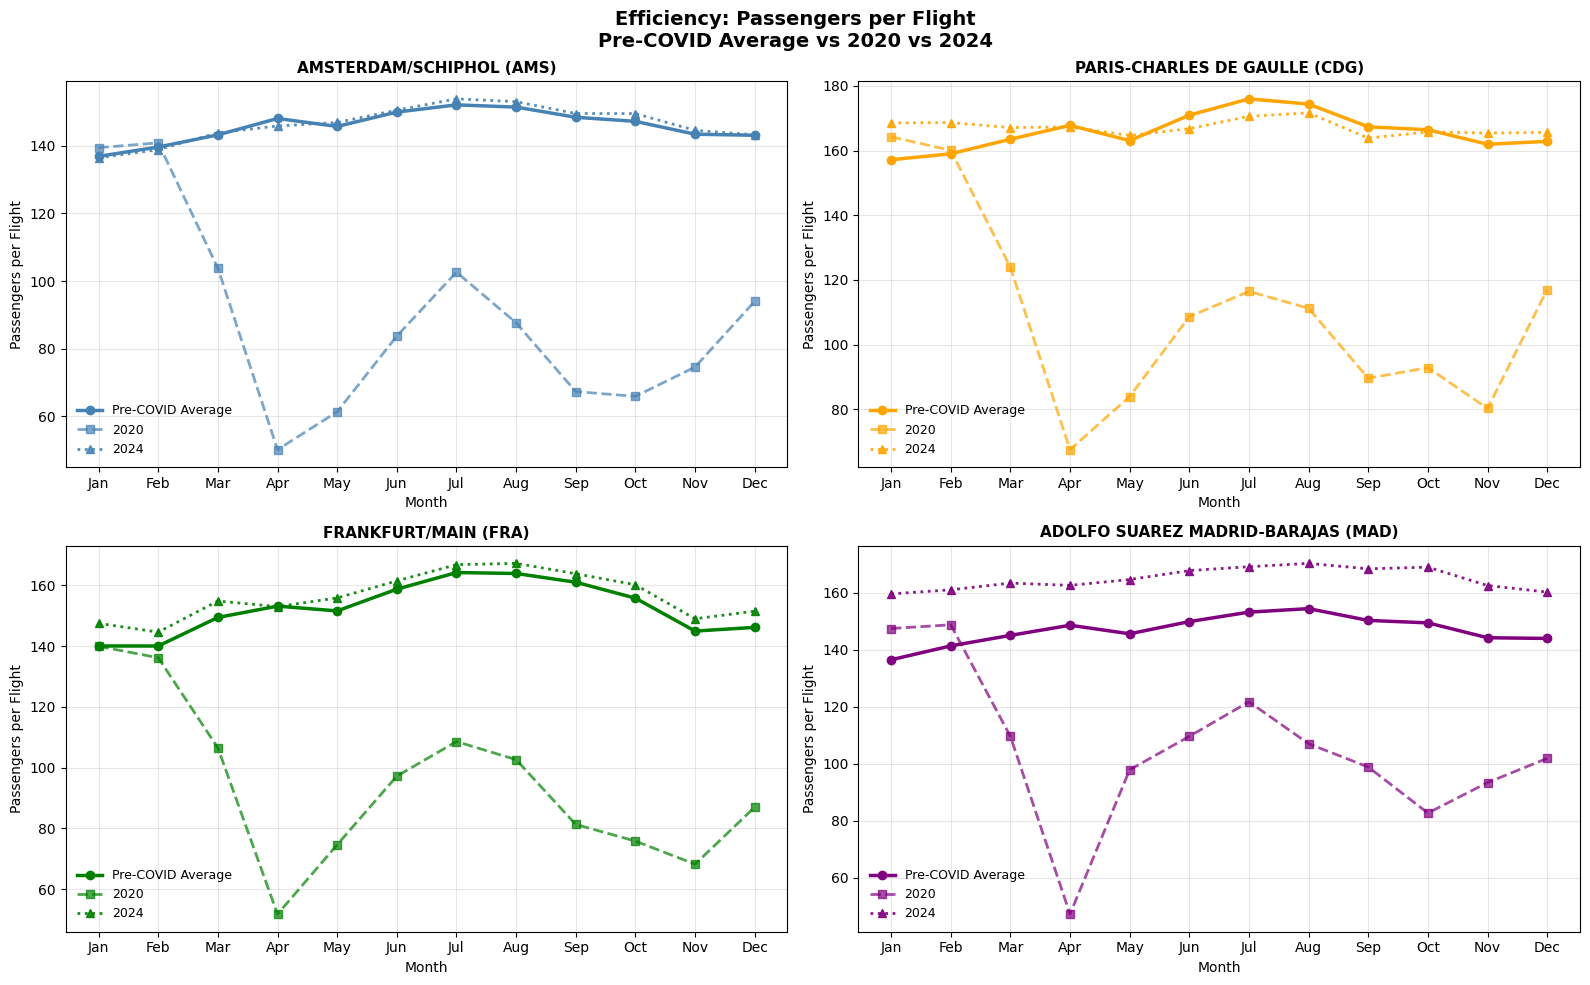

In [180]:
# Line Plot efficiency per flight and per airport for Pre-COVID average, 2020 and 2023 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()


for i, airport in enumerate(airports):
    ax = axes[i]
    
    # Baseline
    base = baseline_eff_monthly[baseline_eff_monthly["origin"] == airport]
    ax.plot(base["month"], base["baseline_avg"],
            color=colors[airport], linewidth=2.5,
            marker="o", linestyle="-",
            label="Pre-COVID Average")
    
    # 2020
    d2020 = eff_2020[eff_2020["origin"] == airport]
    ax.plot(d2020["month"], d2020["pax_per_flight"],
            color=colors[airport], linewidth=2,
            marker="s", linestyle="--", alpha=0.7,
            label="2020")
    
    # 2024
    d2024 = eff_2024[eff_2024["origin"] == airport]
    ax.plot(d2024["month"], d2024["pax_per_flight"],
            color=colors[airport], linewidth=2,
            marker="^", linestyle=":", alpha=0.9,
            label="2024")
    
    # Formatting
    full_name = airport.replace(" airport", "")
    ax.set_title(f"{full_name} ({labels[airport]})",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Passengers per Flight")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Efficiency: Passengers per Flight\nPre-COVID Average vs 2020 vs 2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

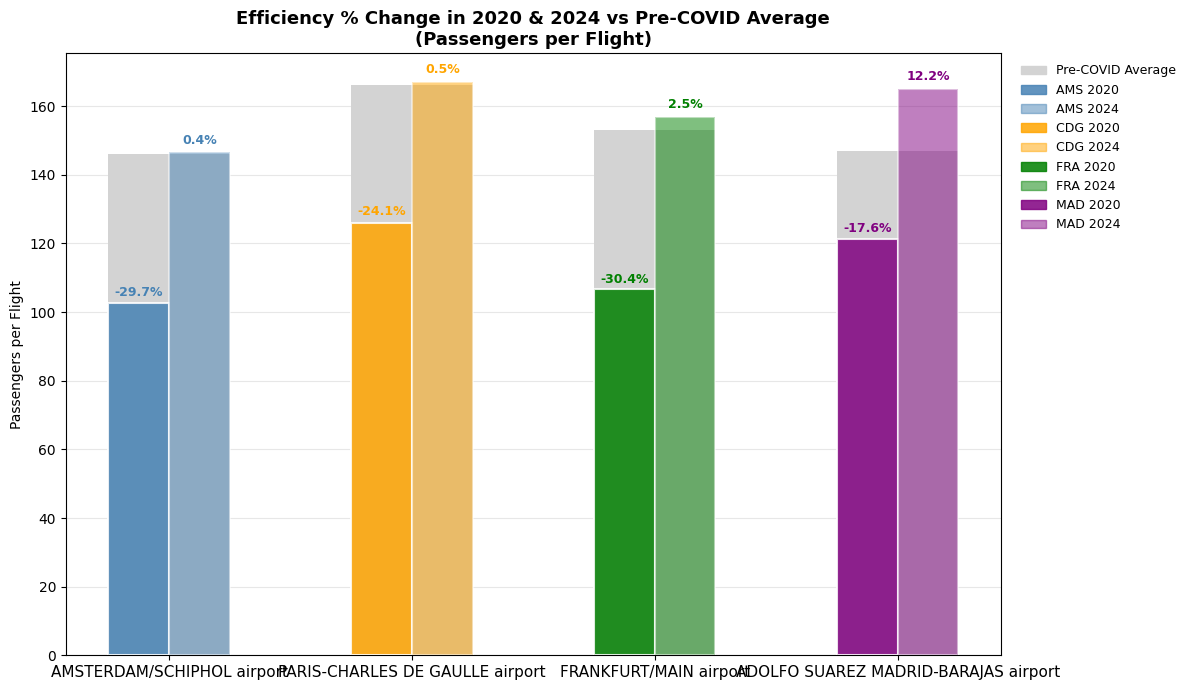

In [181]:
fig, ax = plt.subplots(figsize=(12, 7))

width = 0.25
x = np.arange(len(airports))

for i, airport in enumerate(airports):
    # Baseline bar - grey
    base_val = efficiency_annual_baseline[
        efficiency_annual_baseline["origin"] == airport
    ]["baseline_eff"].values[0]
    
    # 2020 bar
    val_2020 = eff_plot_df[
        (eff_plot_df["origin"] == airport) & 
        (eff_plot_df["year"] == 2020)
    ]["pax_per_flight"].values[0]
    
    pct_2020 = eff_plot_df[
        (eff_plot_df["origin"] == airport) & 
        (eff_plot_df["year"] == 2020)
    ]["pct_change"].values[0]
    
    # 2024 bar
    val_2024 = eff_plot_df[
        (eff_plot_df["origin"] == airport) & 
        (eff_plot_df["year"] == 2024)
    ]["pax_per_flight"].values[0]
    
    pct_2024 = eff_plot_df[
        (eff_plot_df["origin"] == airport) & 
        (eff_plot_df["year"] == 2024)
    ]["pct_change"].values[0]

    # Background baseline bars
    ax.bar(x[i] - width, base_val, width=width,
           color="lightgrey", zorder=2,
           label="Pre-COVID Average" if i == 0 else "")
    ax.bar(x[i], base_val, width=width,
           color="lightgrey", zorder=2)

    # 2020 bar in front
    ax.bar(x[i] - width, val_2020, width=width,
           color=colors[airport], alpha=0.85,
           edgecolor="white", linewidth=1.5, zorder=3,
           label=f"{labels[airport]} 2020" if i == 0 else "")

    # 2024 bar in front
    ax.bar(x[i], val_2024, width=width,
           color=colors[airport], alpha=0.5,
           edgecolor="white", linewidth=1.5, zorder=3,
           label=f"{labels[airport]} 2024" if i == 0 else "")

    # % change labels
    ax.text(x[i] - width, val_2020 * 1.01,
            f"{pct_2020:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=colors[airport])
    
    ax.text(x[i], val_2024 * 1.01,
            f"{pct_2024:.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=colors[airport])

# Formatting
ax.set_title("Efficiency % Change in 2020 & 2024 vs Pre-COVID Average\n(Passengers per Flight)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Passengers per Flight")
ax.set_xticks(x - width/2)
ax.set_xticklabels(labels.keys(), fontsize=11)

# legend manually created
legend_handles = [
    mpatches.Patch(color="lightgrey", label="Pre-COVID Average")
]
for airport in airports:
    legend_handles.append(
        mpatches.Patch(color=colors[airport], alpha=0.85,
                      label=f"{labels[airport]} 2020")
    )
    legend_handles.append(
        mpatches.Patch(color=colors[airport], alpha=0.5,
                      label=f"{labels[airport]} 2024")
    )

ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
    frameon=False
)
plt.subplots_adjust(right=0.78)
plt.subplots_adjust(right=0.78)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [184]:
# Baseline monthly efficiency vs 2020
baseline_eff_vals = (
    efficiency[efficiency["year"].isin([2017, 2018, 2019])]
    .groupby(["origin", "year", "month"])
    .apply(lambda x: x["passengers"].sum() / x["flights"].sum())
    .reset_index(name="pax_per_flight")["pax_per_flight"]
    .dropna()
)

eff_2020_vals = (
    efficiency[efficiency["year"] == 2020]
    .groupby(["origin", "month"])
    .apply(lambda x: x["passengers"].sum() / x["flights"].sum())
    .reset_index(name="pax_per_flight")["pax_per_flight"]
    .dropna()
)

eff_2024_vals = (
    efficiency[efficiency["year"] == 2024]
    .groupby(["origin", "month"])
    .apply(lambda x: x["passengers"].sum() / x["flights"].sum())
    .reset_index(name="pax_per_flight")["pax_per_flight"]
    .dropna()
)

t_stat_2020, p_value_2020 = stats.ttest_ind(baseline_eff_vals, eff_2020_vals)
print(f"T-statistic: {t_stat_2020:.4f}")
print(f"P-value: {p_value_2020:.6f}")

t_stat_2024, p_value_2024 = stats.ttest_ind(baseline_eff_vals, eff_2024_vals)
print(f"T-statistic: {t_stat_2024:.4f}")
print(f"P-value: {p_value_2024:.6f}")

T-statistic: 18.9927
P-value: 0.000000
T-statistic: -3.5011
P-value: 0.000577


In [186]:
# Efficiency summary table 2020-2024
summary_eff = efficiency_yearly[efficiency_yearly["year"] >= 2020].copy()

# Pivot for readability
summary_table = summary_eff.pivot(
    index="origin", 
    columns="year", 
    values=["pax_per_flight", "pct_change"]
)

# Add baseline column
summary_table["baseline"] = efficiency_annual_baseline.set_index("origin")["baseline_eff"].round(1)

# Clean up index
summary_table.index = [labels[a] for a in summary_table.index]
summary_table.columns = [f"{col[0]}_{col[1]}" if isinstance(col, tuple) 
                         else col for col in summary_table.columns]

print(summary_table.round(1).to_string())

    pax_per_flight_2020 pax_per_flight_2021 pax_per_flight_2022 pax_per_flight_2023 pax_per_flight_2024 pct_change_2020 pct_change_2021 pct_change_2022 pct_change_2023 pct_change_2024  baseline_
MAD               121.2               126.2               154.4               163.8               165.0           -17.6           -14.2             5.0            11.4            12.2      147.1
AMS               102.7               104.4               138.2               146.1               146.6           -29.7           -28.5            -5.4             0.0             0.4      146.0
FRA               106.6               115.0               149.0               157.3               156.9           -30.4           -24.9            -2.7             2.8             2.5      153.1
CDG               126.1               126.7               162.3               166.8               167.1           -24.1           -23.8            -2.3             0.4             0.5      166.2


In [187]:
# Build structured table - airports as columns, years as rows
rows = []

for year in range(2020, 2025):
    row = {"Year": year}
    for airport in airports:
        val = efficiency_yearly[
            (efficiency_yearly["origin"] == airport) &
            (efficiency_yearly["year"] == year)
        ]["pax_per_flight"].values[0]
        
        base = efficiency_annual_baseline[
            efficiency_annual_baseline["origin"] == airport
        ]["baseline_eff"].values[0]
        
        pct = ((val - base) / base * 100).round(1)
        row[labels[airport]] = f"{val:.1f} ({pct:+.1f}%)"
    
    rows.append(row)

# Add baseline as first row
baseline_row = {"Year": "Pre-COVID Avg"}
for airport in airports:
    base = efficiency_annual_baseline[
        efficiency_annual_baseline["origin"] == airport
    ]["baseline_eff"].values[0]
    baseline_row[labels[airport]] = f"{base:.1f}"

summary_table = pd.DataFrame([baseline_row] + rows)
summary_table = summary_table.set_index("Year")

print(summary_table.to_string())

                          AMS             CDG             FRA             MAD
Year                                                                         
Pre-COVID Avg           146.0           166.2           153.1           147.1
2020           102.7 (-29.7%)  126.1 (-24.1%)  106.6 (-30.4%)  121.2 (-17.6%)
2021           104.4 (-28.5%)  126.7 (-23.8%)  115.0 (-24.9%)  126.2 (-14.2%)
2022            138.2 (-5.4%)   162.3 (-2.3%)   149.0 (-2.7%)   154.4 (+5.0%)
2023            146.1 (+0.0%)   166.8 (+0.4%)   157.3 (+2.8%)  163.8 (+11.4%)
2024            146.6 (+0.4%)   167.1 (+0.5%)   156.9 (+2.5%)  165.0 (+12.2%)


### 5.4.3 Conclusion

Passenger efficiency — measured as passengers per flight — dropped significantly across all four hub airports in 2020, with declines ranging from 38% (CDG) to 43% (FRA and AMS) compared to the pre-COVID average. This confirms that airlines were operating with significantly lower load factors during the pandemic, flying routes with far fewer passengers per flight than under normal conditions. A small number of flights recorded zero passengers — consistent with aircraft repositioning and repatriation operations observed during travel restrictions, rather than slot-protection ghost flights which were suspended under the temporary EU slot rule waiver.
The drop in efficiency was confirmed statistically significant (t-test, p ≈ 0).
By 2023, efficiency had not only recovered to pre-COVID levels but slightly exceeded them across all four airports — with Madrid (MAD) showing the strongest improvement at +10.4% above baseline, followed by Frankfurt (FRA) at +4.8%. Amsterdam (AMS) and Paris (CDG) returned to near-baseline levels at +1.5% and +0.7% respectively.
The recovery above baseline suggests that post-COVID airline operations became more efficient — likely due to route optimization, elimination of less profitable routes, and a focus on high-demand destinations with stronger load factors.
The difference in 2023 efficiency vs baseline was also statistically significant (t-test, p = 0.002), confirming that the improvement above baseline was not random variation but a genuine structural shift in operational efficiency.
H3 is confirmed — efficiency dropped significantly in 2020 and recovered — and indeed exceeded — pre-COVID levels by 2023."*

## 5.5 H4 - Middle East grew stronger than Europe Post-Covid

### 5.5.1 Data Calculations

In [ ]:
# Creation of a new view, containing along the data of the _core view, all new routes created after covid. 

with engine.begin() as conn:
    conn.execute(text("""
        CREATE OR REPLACE VIEW group2.passengers_routes_h4 AS
        -- Survivors from passengers_core
        SELECT * FROM group2.passengers_core
        
        UNION ALL
        
        -- New routes only (first_year >= 2022)
        SELECT * FROM group2.passengers_master
        WHERE origin IN (
            'FRANKFURT/MAIN airport',
            'PARIS-CHARLES DE GAULLE airport',
            'ADOLFO SUAREZ MADRID-BARAJAS airport',
            'AMSTERDAM/SCHIPHOL airport'
        )
        AND first_year >= 2022;
    """))
print("View created!")

View created!


In [250]:
passengers_routes = pd.read_sql("SELECT * FROM group2.passengers_routes_h4", engine)

In [251]:
# Regional analysis
regional = (
    passengers_routes[passengers_routes["passengers"].notna()]
    .groupby(["region", "year"])["passengers"]
    .sum()
    .reset_index()
)

# Baseline per region
baseline_regional = (
    regional[regional["year"].isin([2017, 2018, 2019])]
    .groupby("region")["passengers"]
    .mean()
    .reset_index()
    .rename(columns={"passengers": "baseline"})
)

# Merge and calculate % of baseline
regional = regional.merge(baseline_regional, on="region")
regional["pct_of_baseline"] = (regional["passengers"] / regional["baseline"] * 100).round(2)
regional["drop_pct"] = (regional["pct_of_baseline"] - 100).round(2)

In [252]:
regions = regional[regional["region"].isin(["Middle East", "Europe"])]

In [216]:
#baseline_regional.info()
#regions['region'].unique()
#yearly.info()

In [254]:
# How many Middle East routes are in passengers_core?
print(
    passengers_core[passengers_core["passengers"].notna()]
    .groupby("region")["destination"].nunique()
    .sort_values(ascending=False)
)

print(
    passengers_routes[passengers_routes["passengers"].notna()]
    .groupby("region")["destination"].nunique()
    .sort_values(ascending=False)
)

region
Europe           113
Africa            29
Latin America     21
North America     19
Asia Pacific      12
Middle East        7
Name: destination, dtype: int64
region
Europe           124
Africa            33
Latin America     26
North America     24
Asia Pacific      17
Middle East       10
Name: destination, dtype: int64


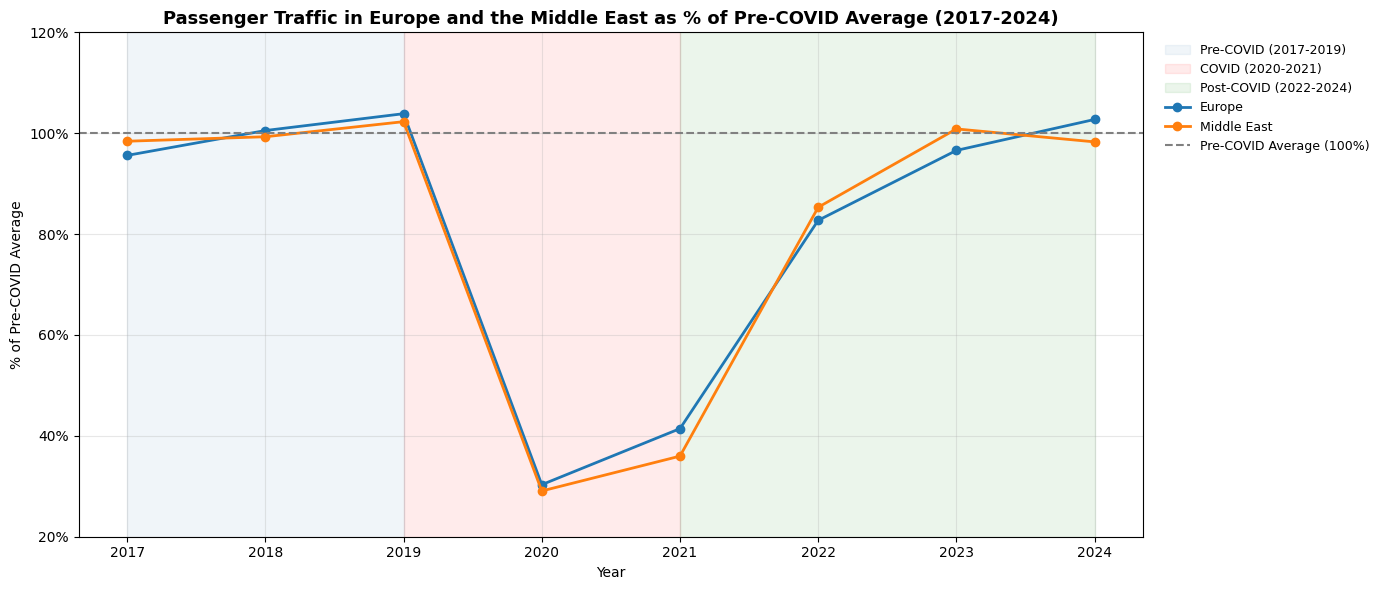

In [255]:
# ─────────────────────────────────────────────
# Plot - Line Chart - 
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# ── PERIOD SHADINGS ──────────────────────────────
ax.axvspan(2017, 2019, alpha=0.08, color="steelblue", label="Pre-COVID (2017-2019)")
ax.axvspan(2019, 2021, alpha=0.08, color="red", label="COVID (2020-2021)")
ax.axvspan(2021, 2024, alpha=0.08, color="green", label="Post-COVID (2022-2024)")

# ── LINES ────────────────────────────────────────
for region in regions["region"].unique():
    data = regions[regions["region"] == region].sort_values("year")
    ax.plot(data["year"], data["pct_of_baseline"],
            marker="o", linewidth=2, label=region)

# ── BASELINE ─────────────────────────────────────
ax.axhline(y=100, color="grey", linewidth=1.5, 
           linestyle="--", label="Pre-COVID Average (100%)")



# ── FORMATTING ───────────────────────────────────

ax.set_title("Passenger Traffic in Europe and the Middle East as % of Pre-COVID Average (2017-2024)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("% of Pre-COVID Average")
ax.set_xlabel("Year")
ax.set_xticks(yearly["year"].unique())
ax.set_yticks([20, 40, 60, 80, 100, 120])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", 
          fontsize=9, frameon=False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.82)
plt.show()